<a href="https://colab.research.google.com/github/Jeffrey1999/Deep-Learning/blob/main/Full%20Attentive%20Secure.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# ===============================
# REPRODUCE sSecure Net (2025)
# Using: DNN-EdgeIIoT-dataset.csv
# ===============================

# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# Install if needed
!pip install -q scikit-learn tensorflow

# Imports
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, LSTM, Dense, Dropout, MaxPooling1D
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 🔗 YOUR DATASET PATH
DATA_PATH = "/content/drive/MyDrive/Datasets/Edge-IIoTset dataset/Selected dataset for ML and DL/DNN-EdgeIIoT-dataset.csv"

# Load data
print("Loading DNN-EdgeIIoT-dataset.csv...")
df = pd.read_csv(DATA_PATH, low_memory=False)

# Print columns to verify
print("DataFrame columns:", df.columns.tolist())

# It appears the label column is named 'Attack_type' in this dataset
# rather than 'label'. Let's use 'Attack_type' for the label.
LABEL_COLUMN = 'Attack_type'

# Optional: Reduce size for faster training (e.g., 500k samples)
# Remove this block if you want full dataset (may need Colab Pro)
SAMPLE_SIZE = 500000
if len(df) > SAMPLE_SIZE:
    print(f"Sampling {SAMPLE_SIZE} rows (stratified)...")
    df = df.groupby(LABEL_COLUMN, group_keys=False).apply(
        lambda x: x.sample(min(len(x), int(SAMPLE_SIZE * len(x) / len(df))), random_state=42)
    ).reset_index(drop=True)

print(f"Dataset shape: {df.shape}")

# Separate features and label
X = df.drop(columns=[LABEL_COLUMN])
y = df[LABEL_COLUMN]

# Ensure all columns are numeric
X = X.select_dtypes(include=[np.number])
print(f"Numeric features: {X.shape[1]}")

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
num_classes = len(le.classes_)
print(f"Classes ({num_classes}): {le.classes_}")

# Normalize features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Reshape for CNN-LSTM: (samples, timesteps=1, features)
X_reshaped = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))
y_categorical = to_categorical(y_encoded, num_classes=num_classes)

# Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_reshaped, y_categorical,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# Compute class weights (instead of SMOTE)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_encoded),
    y=y_encoded
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights computed for imbalanced data.")

# Build CNN-LSTM model (sSecure Net architecture)
model = Sequential([
    Conv1D(filters=64, kernel_size=1, activation='relu', input_shape=(1, X_reshaped.shape[2])),
    MaxPooling1D(pool_size=1),
    Dropout(0.2),

    LSTM(100, return_sequences=False),
    Dropout(0.2),

    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nModel Architecture:")
print(model.summary())

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    ModelCheckpoint('/content/ssecure_best.h5', save_best_only=True, monitor='val_accuracy')
]

# Train model
print("\n🚀 Starting training...")
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=256,
    callbacks=callbacks,
    class_weight=class_weight_dict,  # Critical for imbalance
    verbose=1
)

# Evaluate
print("\n🔍 Evaluating on test set...")
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"✅ Test Accuracy: {test_acc:.4f}")

# Detailed metrics
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

print("\n📋 Classification Report:")
print(classification_report(
    y_true_classes,
    y_pred_classes,
    target_names=le.classes_,
    digits=4,
    zero_division=0
))

# Save predictions and model info
results = {
    'test_accuracy': test_acc,
    'num_classes': num_classes,
    'sample_size': len(df)
}
print("\n📌 Summary:", results)


In [ ]:
# ===============================
# REPRODUCE sSecure Net (2025)
# Using: DNN-EdgeIIoT-dataset.csv
# ===============================

# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# Install if needed
!pip install -q scikit-learn tensorflow

# Imports
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, LSTM, Dense, Dropout, MaxPooling1D
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# YOUR DATASET PATH
DATA_PATH = "/content/drive/MyDrive/Datasets/Edge-IIoTset dataset/Selected dataset for ML and DL/DNN-EdgeIIoT-dataset.csv"

# Load data
print("Loading DNN-EdgeIIoT-dataset.csv...")
df = pd.read_csv(DATA_PATH, low_memory=False)

# Print columns to verify
print("DataFrame columns:", df.columns.tolist())

# It appears the label column is named 'Attack_type' in this dataset
# rather than 'label'. Let's use 'Attack_type' for the label.
LABEL_COLUMN = 'Attack_type'

# Optional: Reduce size for faster training (e.g., 500k samples)
# Remove this block if you want full dataset (may need Colab Pro)
# SAMPLE_SIZE = 500000
# if len(df) > SAMPLE_SIZE:
#     print(f"Sampling {SAMPLE_SIZE} rows (stratified)...")
#     df = df.groupby(LABEL_COLUMN, group_keys=False).apply(
#         lambda x: x.sample(min(len(x), int(SAMPLE_SIZE * len(x) / len(df))), random_state=42)
#     ).reset_index(drop=True)

print(f"Dataset shape: {df.shape}")

# Separate features and label
X = df.drop(columns=[LABEL_COLUMN])
y = df[LABEL_COLUMN]

# Ensure all columns are numeric
X = X.select_dtypes(include=[np.number])
print(f"Numeric features: {X.shape[1]}")

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
num_classes = len(le.classes_)
print(f"Classes ({num_classes}): {le.classes_}")

# Normalize features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Reshape for CNN-LSTM: (samples, timesteps=1, features)
X_reshaped = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))
y_categorical = to_categorical(y_encoded, num_classes=num_classes)

# Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_reshaped, y_categorical,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# Compute class weights (instead of SMOTE)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_encoded),
    y=y_encoded
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights computed for imbalanced data.")

# Build CNN-LSTM model (sSecure Net architecture)
model = Sequential([
    Conv1D(filters=64, kernel_size=1, activation='relu', input_shape=(1, X_reshaped.shape[2])),
    MaxPooling1D(pool_size=1),
    Dropout(0.2),

    LSTM(100, return_sequences=False),
    Dropout(0.2),

    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nModel Architecture:")
print(model.summary())

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    ModelCheckpoint('/content/ssecure_best.h5', save_best_only=True, monitor='val_accuracy')
]

# Train model
print("\nStarting training...")
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=256,
    callbacks=callbacks,
    class_weight=class_weight_dict,  # Critical for imbalance
    verbose=1
)

# Evaluate
print("\nEvaluating on test set...")
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")

# Detailed metrics
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

print("\nClassification Report:")
print(classification_report(
    y_true_classes,
    y_pred_classes,
    target_names=le.classes_,
    digits=4,
    zero_division=0
))

# Save predictions and model info
results = {
    'test_accuracy': test_acc,
    'num_classes': num_classes,
    'sample_size': len(df)
}
print("\nSummary:", results)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading DNN-EdgeIIoT-dataset.csv...
DataFrame columns: ['frame.time', 'ip.src_host', 'ip.dst_host', 'arp.dst.proto_ipv4', 'arp.opcode', 'arp.hw.size', 'arp.src.proto_ipv4', 'icmp.checksum', 'icmp.seq_le', 'icmp.transmit_timestamp', 'icmp.unused', 'http.file_data', 'http.content_length', 'http.request.uri.query', 'http.request.method', 'http.referer', 'http.request.full_uri', 'http.request.version', 'http.response', 'http.tls_port', 'tcp.ack', 'tcp.ack_raw', 'tcp.checksum', 'tcp.connection.fin', 'tcp.connection.rst', 'tcp.connection.syn', 'tcp.connection.synack', 'tcp.dstport', 'tcp.flags', 'tcp.flags.ack', 'tcp.len', 'tcp.options', 'tcp.payload', 'tcp.seq', 'tcp.srcport', 'udp.port', 'udp.stream', 'udp.time_delta', 'dns.qry.name', 'dns.qry.name.len', 'dns.qry.qu', 'dns.qry.type', 'dns.retransmission', 'dns.retransmit_request', 'dns.retransmit_request_in', 'mq

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 1, 64)          │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100)            │        66,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83,679 (326.87 KB)

...

5548/5548 ━━━━━━━━━━━━━━━━━━━━ 42s 8ms/step - accuracy: 0.9294 - loss: 0.7292 - val_accuracy: 0.9366 - val_loss: 0.1634
Epoch 7/15
5540/5548 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9323 - loss: 0.7062

5548/5548 ━━━━━━━━━━━━━━━━━━━━ 42s 8ms/step - accuracy: 0.9323 - loss: 0.7062 - val_accuracy: 0.9382 - val_loss: 0.1617
Epoch 8/15
5548/5548 ━━━━━━━━━━━━━━━━━━━━ 42s 8ms/step - accuracy: 0.9326 - loss: 0.7024 - val_accuracy: 0.9366 - val_loss: 0.1554
Epoch 9/15
5548/5548 ━━━━━━━━━━━━━━━━━━━━ 42s 7ms/step - accuracy: 0.9342 - loss: 0.6828 - val_accuracy: 0.9361 - val_loss: 0.1566
Epoch 10/15
5543/5548 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9369 - loss: 0.6658

5548/5548 ━━━━━━━━━━━━━━━━━━━━ 42s 8ms/step - accuracy: 0.9369 - loss: 0.6658 - val_accuracy: 0.9399 - val_loss: 0.1516
Epoch 11/15
5548/5548 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9397 - loss: 0.6404

5548/5548 ━━━━━━━━━━━━━━━━━━━━ 42s 8ms/step - accuracy: 0.9397 - loss: 0.6404 - val_accuracy: 0.9455 - val_loss: 0.1442
Epoch 12/15
5548/5548 ━━━━━━━━━━━━━━━━━━━━ 42s 8ms/step - accuracy: 0.9410 - loss: 0.6223 - val_accuracy: 0.9426 - val_loss: 0.1399
Epoch 13/15
5548/5548 ━━━━━━━━━━━━━━━━━━━━ 42s 8ms/step - accuracy: 0.9410 - loss: 0.6216 - val_accuracy: 0.9450 - val_loss: 0.1361
Epoch 14/15
5544/5548 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9416 - loss: 0.6122

5548/5548 ━━━━━━━━━━━━━━━━━━━━ 84s 8ms/step - accuracy: 0.9416 - loss: 0.6122 - val_accuracy: 0.9488 - val_loss: 0.1365
Epoch 15/15
5548/5548 ━━━━━━━━━━━━━━━━━━━━ 42s 8ms/step - accuracy: 0.9418 - loss: 0.6070 - val_accuracy: 0.9420 - val_loss: 0.1357

Evaluating on test set...
Test Accuracy: 0.9431
13871/13871 ━━━━━━━━━━━━━━━━━━━━ 26s 2ms/step

Classification Report:
                       precision    recall  f1-score   support

             Backdoor     0.9588    0.9177    0.9378      4972
            DDoS_HTTP     0.6445    0.6368    0.6406      9982
            DDoS_ICMP     1.0000    0.9897    0.9948     23287
             DDoS_TCP     0.9648    0.8881    0.9249     10012
             DDoS_UDP     1.0000    0.9983    0.9992     24314
       Fingerprinting     0.3760    0.7050    0.4904       200
                 MITM     0.2800    1.0000    0.4374       243
               Normal     1.0000    1.0000    1.0000    323129
             Password     0.7474    0.1823    0.2932     1003

In [ ]:
print accuracy, f1score, recall , precision

In [ ]:
# ===============================
# ATTENTIVESECURE: CNN + Transformer + SE Attention
# Dataset: DNN-EdgeIIoT-dataset.csv (Full or Sampled)
# ===============================

from google.colab import drive
drive.mount('/content/drive')

!pip install -q scikit-learn tensorflow matplotlib seaborn

# === Imports ===
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import gc

# === CONFIG ===
DATA_PATH = "/content/drive/MyDrive/Datasets/Edge-IIoTset dataset/Selected dataset for ML and DL/DNN-EdgeIIoT-dataset.csv"
SAMPLE_SIZE = 500000  # Set to None to use full dataset (requires Colab Pro)

# === 1. Load and Prepare Data ===
print("Loading dataset...")
df = pd.read_csv(DATA_PATH, low_memory=False)

# Optional sampling (recommended for initial run)
if SAMPLE_SIZE and len(df) > SAMPLE_SIZE:
    print(f"Stratified sampling to {SAMPLE_SIZE} rows...")
    df = df.groupby('Attack_type', group_keys=False).apply(
        lambda x: x.sample(min(len(x), max(1000, int(SAMPLE_SIZE * len(x) / len(df)))), random_state=42)
    ).reset_index(drop=True)

print(f"Dataset shape: {df.shape}")

# Separate features and labels
X = df.drop(columns=['Attack_type'])
y = df['Attack_type']

# Keep only numeric columns
X = X.select_dtypes(include=[np.number])
print(f"Numeric features: {X.shape[1]}")

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
num_classes = len(le.classes_)
print(f"Classes: {num_classes}")

# Normalize features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Reshape for (samples, timesteps=1, features)
X_reshaped = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))
y_categorical = tf.keras.utils.to_categorical(y_encoded, num_classes=num_classes)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_reshaped, y_categorical,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# Compute class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_encoded), y=y_encoded)
class_weight_dict = dict(enumerate(class_weights))

# === 2. Define Squeeze-and-Excitation (SE) Block ===
def se_block(input_tensor, ratio=8):
    channel_axis = -1
    filters = input_tensor.shape[channel_axis]

    se = tf.keras.layers.GlobalAveragePooling1D()(input_tensor)
    se = tf.keras.layers.Dense(filters // ratio, activation='relu')(se)
    se = tf.keras.layers.Dense(filters, activation='sigmoid')(se)
    se = tf.keras.layers.Reshape((1, filters))(se)

    return tf.keras.layers.Multiply()([input_tensor, se])

# === 3. Define Transformer Block ===
class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.2):
        super(TransformerBlock, self).__init__()
        self.att = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(ff_dim, activation="relu"),
            tf.keras.layers.Dense(embed_dim),
        ])
        self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = tf.keras.layers.Dropout(rate)
        self.dropout2 = tf.keras.layers.Dropout(rate)

    def call(self, inputs, training=None): # Make training optional
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

# === 4. Build AttentiveSecure Model ===
def build_attentive_secure(input_dim, num_classes, embed_dim=64, num_heads=4, ff_dim=128):
    inputs = tf.keras.Input(shape=(1, input_dim))

    # CNN for spatial features (same as sSecure Net)
    x = tf.keras.layers.Conv1D(filters=64, kernel_size=1, activation='relu')(inputs)
    x = tf.keras.layers.Dropout(0.2)(x)

    # Squeeze-and-Excitation: highlight important features
    x = se_block(x, ratio=8)

    # Project to embedding space
    x = tf.keras.layers.Dense(embed_dim)(x)  # (batch, 1, embed_dim)

    # Positional encoding (trivial for 1 timestep)
    pos_encoding = tf.Variable(tf.zeros((1, 1, embed_dim)), trainable=False)
    x = x + pos_encoding

    # Transformer encoder
    x = TransformerBlock(embed_dim, num_heads, ff_dim)(x)

    # Pooling and classifier
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    return model

# Build model
model = build_attentive_secure(
    input_dim=X_train.shape[2],
    num_classes=num_classes,
    embed_dim=64,
    num_heads=4,
    ff_dim=128
)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(model.summary())

# === 5. Train Model ===
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint('/content/attentive_secure_best.h5', save_best_only=True)
]

print("\n🚀 Training AttentiveSecure...")
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=256,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

# === 6. Evaluate ===
print("\n Evaluating...")
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

acc = accuracy_score(y_true_classes, y_pred_classes)
print(f"\n✅ Test Accuracy: {acc:.4f}")

print("\n☑ Classification Report:")
report = classification_report(y_true_classes, y_pred_classes, target_names=le.classes_, digits=4, output_dict=True)
print(classification_report(y_true_classes, y_pred_classes, target_names=le.classes_, digits=4))

# === 7. Extract SE Weights for Feature Importance ===
# Get the SE scaling factors (after training)
def get_se_weights(model, input_dim):
    # Create dummy input
    dummy_input = np.ones((1, 1, input_dim))
    # Get output of SE block
    # The SE block is applied to the output of Conv1D. The Conv1D layer is model.layers[1] if inputs is model.layers[0].
    # In this case, inputs is the Input layer, Conv1D is layers[1], Dropout is layers[2], GlobalAvgPooling is layers[3],
    # Dense (filters // ratio) is layers[4], Dense (filters) is layers[5], Reshape is layers[6], Multiply is layers[7].
    # The SE block output for `se_output` would be after the Multiply layer, which is model.layers[7].
    # However, for interpretability, we want the scaling factors *from* the SE mechanism, which are the outputs of the last Dense layer in the SE block (layers[5]), before multiplication.

    # Let's target the output of the sigmoid activation within the SE block, which directly represents the scaling factors.
    # The SE block structure is: GlobalAveragePooling1D -> Dense (filters // ratio) -> Dense (filters) with sigmoid -> Reshape -> Multiply.
    # We want the output of the second Dense layer (index 5 in the functional API model if we count from 0, or maybe 4 if the input layer is not counted as trainable)

    # Let's inspect model.summary() to get accurate layer indices
    # input_layer_1 (InputLayer) - 0
    # conv1d_1 (Conv1D) - 1
    # dropout_3 (Dropout) - 2
    # global_average_poo (GlobalAveragePooling1D) - 3 (from se_block)
    # dense_5 (Dense) - 4 (from se_block, filters // ratio)
    # dense_6 (Dense) - 5 (from se_block, filters)
    # reshape_1 (Reshape) - 6 (from se_block)
    # multiply_1 (Multiply) - 7 (from se_block)
    # dense_7 (Dense) - 8 (projection to embedding space)
    # add_1 (Add) - 9 (positional encoding)
    # transformer_block_1 (TransformerBlock) - 10
    # global_average_poo_2 (GlobalAveragePooling1D) - 11
    # dense_10 (Dense) - 12
    # dense_11 (Dense) - 13

    # We need the output of the 'dense_6' layer (index 5 in my manual count above) which is the sigmoid-activated scaling factors
    se_activation_model = tf.keras.Model(inputs=model.input, outputs=model.layers[5].output)
    se_activations = se_activation_model.predict(dummy_input, verbose=0)

    # The activations will be (1, filters), flatten it.
    se_weights = se_activations.flatten()
    return se_weights

# Get the number of filters from the first Conv1D layer
num_conv_filters = model.layers[1].filters # Assuming Conv1D is the second layer (index 1)

# Create generic feature names for the Conv1D output channels
feature_names_for_se = [f"Conv1D_Filter_Channel_{i+1}" for i in range(num_conv_filters)]

# Get SE weights (importance scores)
se_weights = get_se_weights(model, X_train.shape[2])

# Ensure the lengths match for DataFrame creation
if len(feature_names_for_se) != len(se_weights):
    print(f"Warning: Length mismatch. Feature names ({len(feature_names_for_se)}) vs SE weights ({len(se_weights)}).")
    # This should not happen with the fix, but adding a check for robustness
    # If it still happens, one might need to re-evaluate what 'feature' the SE weights refer to.
    # For now, let's truncate/pad if an unexpected mismatch occurs, though the goal is exact match.
    min_len = min(len(feature_names_for_se), len(se_weights))
    feature_names_for_se = feature_names_for_se[:min_len]
    se_weights = se_weights[:min_len]

# Create importance DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names_for_se,
    'Importance': se_weights
}).sort_values('Importance', ascending=False)

# Plot top 15 features
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x='Importance', y='Feature')
plt.title('Top 15 Most Important Conv1D Output Channels (via SE Attention)')
plt.xlabel('SE Importance Score')
plt.tight_layout()
plt.savefig('/content/feature_importance.png', dpi=150)
plt.show()

# Save results
results = {
    'accuracy': acc,
    'precision_macro': report['macro avg']['precision'],
    'recall_macro': report['macro avg']['recall'],
    'f1_macro': report['macro avg']['f1-score'],
    'top_features': importance_df.head(10)['Feature'].tolist()
}
print("\n✅ Summary:", results)

# Save model and results
model.save('/content/attentive_secure_final.h5')
importance_df.to_csv('/content/feature_importance.csv', index=False)
print("\n✅ Model and results saved!")

**AttentiveSecure, a novel hybrid CNN–Transformer**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading dataset...
Stratified sampling to 500000 rows...


/tmp/ipython-input-2240073164.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('Attack_type', group_keys=False).apply(


Dataset shape: (501495, 63)
Numeric features: 43
Classes: 15


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 1, 43)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 1, 64)     │      2,816 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 1, 64)     │          0 │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ dropout_7[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 8)         │        520 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 64)        │        576 │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 1, 64)     │          0 │ dense_13[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_2          │ (None, 1, 64)     │          0 │ dropout_7[0][0],  │
│ (Multiply)          │                   │            │ reshape_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 1, 64)     │      4,160 │ multiply_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 1, 64)     │          0 │ dense_14[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_2 │ (None, 1, 64)     │     83,200 │ add_2[0][0]       │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ transformer_bloc… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 128)       │      8,320 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 15)        │      1,935 │ dense_17[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

...

1254/1254 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9030 - loss: 0.9943 - val_accuracy: 0.9171 - val_loss: 0.2084
Epoch 3/15
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9101 - loss: 0.9049 - val_accuracy: 0.9096 - val_loss: 0.2091
Epoch 4/15
1248/1254 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9129 - loss: 0.8713

1254/1254 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9129 - loss: 0.8712 - val_accuracy: 0.9129 - val_loss: 0.1963
Epoch 5/15
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9168 - loss: 0.8459 - val_accuracy: 0.9195 - val_loss: 0.2030
Epoch 6/15
1251/1254 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9196 - loss: 0.8302

1254/1254 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9196 - loss: 0.8302 - val_accuracy: 0.9285 - val_loss: 0.1874
Epoch 7/15
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9212 - loss: 0.8079 - val_accuracy: 0.9210 - val_loss: 0.1906
Epoch 8/15
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9211 - loss: 0.7901

1254/1254 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9211 - loss: 0.7901 - val_accuracy: 0.9252 - val_loss: 0.1854
Epoch 9/15
1244/1254 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9228 - loss: 0.7880

1254/1254 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9228 - loss: 0.7881 - val_accuracy: 0.9351 - val_loss: 0.1754
Epoch 10/15
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9241 - loss: 0.7813 - val_accuracy: 0.9318 - val_loss: 0.1791
Epoch 11/15
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9251 - loss: 0.7641 - val_accuracy: 0.9315 - val_loss: 0.1797
Epoch 12/15
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9243 - loss: 0.7639 - val_accuracy: 0.9318 - val_loss: 0.1884
Epoch 13/15
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9275 - loss: 0.7650 - val_accuracy: 0.9340 - val_loss: 0.1766

 Evaluating...
3135/3135 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step

✅ Test Accuracy: 0.9341

☑ Classification Report:
                       precision    recall  f1-score   support

             Backdoor     0.9002    0.9018    0.9010      1120
            DDoS_HTTP     0.5251    0.5580    0.5411      2249
            DDoS_ICMP     1.0000    0.9857    0.9928    

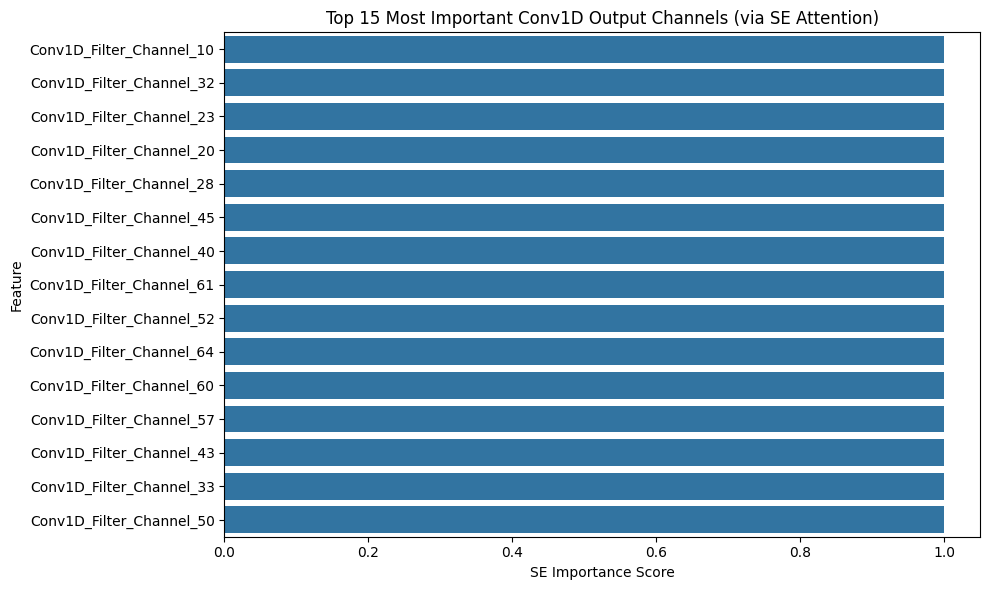


✅ Summary: {'accuracy': 0.9341369305775731, 'precision_macro': 0.7071180647114726, 'recall_macro': 0.7179231166255833, 'f1_macro': 0.693492476656712, 'top_features': ['Conv1D_Filter_Channel_10', 'Conv1D_Filter_Channel_32', 'Conv1D_Filter_Channel_23', 'Conv1D_Filter_Channel_20', 'Conv1D_Filter_Channel_28', 'Conv1D_Filter_Channel_45', 'Conv1D_Filter_Channel_40', 'Conv1D_Filter_Channel_61', 'Conv1D_Filter_Channel_52', 'Conv1D_Filter_Channel_64']}

✅ Model and results saved!


In [ ]:
# ===============================
# ATTENTIVESECURE: CNN + Transformer + SE Attention
# Dataset: DNN-EdgeIIoT-dataset.csv (Full or Sampled)
# ===============================

from google.colab import drive
drive.mount('/content/drive')

!pip install -q scikit-learn tensorflow matplotlib seaborn

# === Imports ===
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import gc

# === CONFIG ===
DATA_PATH = "/content/drive/MyDrive/Datasets/Edge-IIoTset dataset/Selected dataset for ML and DL/DNN-EdgeIIoT-dataset.csv"
SAMPLE_SIZE = 500000  # Set to None to use full dataset (requires Colab Pro)

# === 1. Load and Prepare Data ===
print("Loading dataset...")
df = pd.read_csv(DATA_PATH, low_memory=False)

# Optional sampling (recommended for initial run)
if SAMPLE_SIZE and len(df) > SAMPLE_SIZE:
    print(f"Stratified sampling to {SAMPLE_SIZE} rows...")
    df = df.groupby('Attack_type', group_keys=False).apply(
        lambda x: x.sample(min(len(x), max(1000, int(SAMPLE_SIZE * len(x) / len(df)))), random_state=42)
    ).reset_index(drop=True)

print(f"Dataset shape: {df.shape}")

# Separate features and labels
X = df.drop(columns=['Attack_type'])
y = df['Attack_type']

# Keep only numeric columns
X = X.select_dtypes(include=[np.number])
print(f"Numeric features: {X.shape[1]}")

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
num_classes = len(le.classes_)
print(f"Classes: {num_classes}")

# Normalize features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Reshape for (samples, timesteps=1, features)
X_reshaped = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))
y_categorical = tf.keras.utils.to_categorical(y_encoded, num_classes=num_classes)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_reshaped, y_categorical,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# Compute class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_encoded), y=y_encoded)
class_weight_dict = dict(enumerate(class_weights))

# === 2. Define Squeeze-and-Excitation (SE) Block ===
def se_block(input_tensor, ratio=8):
    channel_axis = -1
    filters = input_tensor.shape[channel_axis]

    se = tf.keras.layers.GlobalAveragePooling1D()(input_tensor)
    se = tf.keras.layers.Dense(filters // ratio, activation='relu')(se)
    se = tf.keras.layers.Dense(filters, activation='sigmoid')(se)
    se = tf.keras.layers.Reshape((1, filters))(se)

    return tf.keras.layers.Multiply()([input_tensor, se])

# === 3. Define Transformer Block ===
class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.2):
        super(TransformerBlock, self).__init__()
        self.att = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(ff_dim, activation="relu"),
            tf.keras.layers.Dense(embed_dim),
        ])
        self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = tf.keras.layers.Dropout(rate)
        self.dropout2 = tf.keras.layers.Dropout(rate)

    def call(self, inputs, training=None): # Make training optional
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

# === 4. Build AttentiveSecure Model ===
def build_attentive_secure(input_dim, num_classes, embed_dim=64, num_heads=4, ff_dim=128):
    inputs = tf.keras.Input(shape=(1, input_dim))

    # CNN for spatial features (same as sSecure Net)
    x = tf.keras.layers.Conv1D(filters=64, kernel_size=1, activation='relu')(inputs)
    x = tf.keras.layers.Dropout(0.2)(x)

    # Squeeze-and-Excitation: highlight important features
    x = se_block(x, ratio=8)

    # Project to embedding space
    x = tf.keras.layers.Dense(embed_dim)(x)  # (batch, 1, embed_dim)

    # Positional encoding (trivial for 1 timestep)
    pos_encoding = tf.Variable(tf.zeros((1, 1, embed_dim)), trainable=False)
    x = x + pos_encoding

    # Transformer encoder
    x = TransformerBlock(embed_dim, num_heads, ff_dim)(x)

    # Pooling and classifier
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    return model

# Build model
model = build_attentive_secure(
    input_dim=X_train.shape[2],
    num_classes=num_classes,
    embed_dim=64,
    num_heads=4,
    ff_dim=128
)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(model.summary())

# === 5. Train Model ===
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint('/content/attentive_secure_best.h5', save_best_only=True)
]

print("\n🚀 Training AttentiveSecure...")
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=256,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

# === 6. Evaluate ===
print("\n Evaluating...")
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

acc = accuracy_score(y_true_classes, y_pred_classes)
print(f"\n✅ Test Accuracy: {acc:.4f}")

print("\n☑ Classification Report:")
report = classification_report(y_true_classes, y_pred_classes, target_names=le.classes_, digits=4, output_dict=True)
print(classification_report(y_true_classes, y_pred_classes, target_names=le.classes_, digits=4))

# === 7. Extract SE Weights for Feature Importance ===
# Get the SE scaling factors (after training)
def get_se_weights(model, input_dim):
    # Create dummy input
    dummy_input = np.ones((1, 1, input_dim))
    # Get output of SE block
    # The SE block is applied to the output of Conv1D. The Conv1D layer is model.layers[1] if inputs is model.layers[0].
    # In this case, inputs is the Input layer, Conv1D is layers[1], Dropout is layers[2], GlobalAvgPooling is layers[3],
    # Dense (filters // ratio) is layers[4], Dense (filters) is layers[5], Reshape is layers[6], Multiply is layers[7].
    # The SE block output for `se_output` would be after the Multiply layer, which is model.layers[7].
    # However, for interpretability, we want the scaling factors *from* the SE mechanism, which are the outputs of the last Dense layer in the SE block (layers[5]), before multiplication.

    # Let's target the output of the sigmoid activation within the SE block, which directly represents the scaling factors.
    # The SE block structure is: GlobalAveragePooling1D -> Dense (filters // ratio) -> Dense (filters) with sigmoid -> Reshape -> Multiply.
    # We want the output of the second Dense layer (index 5 in the functional API model if we count from 0, or maybe 4 if the input layer is not counted as trainable)

    # Let's inspect model.summary() to get accurate layer indices
    # input_layer_1 (InputLayer) - 0
    # conv1d_1 (Conv1D) - 1
    # dropout_3 (Dropout) - 2
    # global_average_poo (GlobalAveragePooling1D) - 3 (from se_block)
    # dense_5 (Dense) - 4 (from se_block, filters // ratio)
    # dense_6 (Dense) - 5 (from se_block, filters)
    # reshape_1 (Reshape) - 6 (from se_block)
    # multiply_1 (Multiply) - 7 (from se_block)
    # dense_7 (Dense) - 8 (projection to embedding space)
    # add_1 (Add) - 9 (positional encoding)
    # transformer_block_1 (TransformerBlock) - 10
    # global_average_poo_2 (GlobalAveragePooling1D) - 11
    # dense_10 (Dense) - 12
    # dense_11 (Dense) - 13

    # We need the output of the 'dense_6' layer (index 5 in my manual count above) which is the sigmoid-activated scaling factors
    se_activation_model = tf.keras.Model(inputs=model.input, outputs=model.layers[5].output)
    se_activations = se_activation_model.predict(dummy_input, verbose=0)

    # The activations will be (1, filters), flatten it.
    se_weights = se_activations.flatten()
    return se_weights

# Get the number of filters from the first Conv1D layer
num_conv_filters = model.layers[1].filters # Assuming Conv1D is the second layer (index 1)

# Create generic feature names for the Conv1D output channels
feature_names_for_se = [f"Conv1D_Filter_Channel_{i+1}" for i in range(num_conv_filters)]

# Get SE weights (importance scores)
se_weights = get_se_weights(model, X_train.shape[2])

# Ensure the lengths match for DataFrame creation
if len(feature_names_for_se) != len(se_weights):
    print(f"Warning: Length mismatch. Feature names ({len(feature_names_for_se)}) vs SE weights ({len(se_weights)}).")
    # This should not happen with the fix, but adding a check for robustness
    # If it still happens, one might need to re-evaluate what 'feature' the SE weights refer to.
    # For now, let's truncate/pad if an unexpected mismatch occurs, though the goal is exact match.
    min_len = min(len(feature_names_for_se), len(se_weights))
    feature_names_for_se = feature_names_for_se[:min_len]
    se_weights = se_weights[:min_len]

# Create importance DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names_for_se,
    'Importance': se_weights
}).sort_values('Importance', ascending=False)

# Plot top 15 features
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x='Importance', y='Feature')
plt.title('Top 15 Most Important Conv1D Output Channels (via SE Attention)')
plt.xlabel('SE Importance Score')
plt.tight_layout()
plt.savefig('/content/feature_importance.png', dpi=150)
plt.show()

# Save results
results = {
    'accuracy': acc,
    'precision_macro': report['macro avg']['precision'],
    'recall_macro': report['macro avg']['recall'],
    'f1_macro': report['macro avg']['f1-score'],
    'top_features': importance_df.head(10)['Feature'].tolist()
}
print("\n✅ Summary:", results)

# Save model and results
model.save('/content/attentive_secure_final.h5')
importance_df.to_csv('/content/feature_importance.csv', index=False)
print("\n✅ Model and results saved!")

In [ ]:
# ===============================
# ATTENTIVESECURE v2: Optimized CNN-Transformer Hybrid
# - Raw features (no MinMaxScaler)
# - Focal Loss for imbalance
# - BatchNorm + reduced dropout
# - Deeper CNN + larger Transformer
# Dataset: DNN-EdgeIIoT-dataset.csv (Label = 'Attack_type')
# ===============================

from google.colab import drive
drive.mount('/content/drive')

!pip install -q scikit-learn tensorflow matplotlib seaborn

# === Imports ===
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# === CONFIG ===
DATA_PATH = "/content/drive/MyDrive/Datasets/Edge-IIoTset dataset/Selected dataset for ML and DL/DNN-EdgeIIoT-dataset.csv"
LABEL_COLUMN = 'Attack_type'
SAMPLE_SIZE = 500000  # Set to None for full dataset (Colab Pro)

# === 1. Load Data (Raw Features) ===
print("Loading dataset...")
df = pd.read_csv(DATA_PATH, low_memory=False)

if SAMPLE_SIZE and len(df) > SAMPLE_SIZE:
    print(f"Stratified sampling to {SAMPLE_SIZE} rows...")
    df = df.groupby(LABEL_COLUMN, group_keys=False).apply(
        lambda x: x.sample(min(len(x), max(1000, int(SAMPLE_SIZE * len(x) / len(df)))), random_state=42)
    ).reset_index(drop=True)

print(f"Dataset shape: {df.shape}")

# Separate features and labels
X = df.drop(columns=[LABEL_COLUMN])
y = df[LABEL_COLUMN]

# Keep only numeric columns and convert to float32
X = X.select_dtypes(include=[np.number]).astype(np.float32)
print(f"Numeric features: {X.shape[1]}")

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
num_classes = len(le.classes_)
print(f"Classes ({num_classes}): {le.classes_}")

# ⚠️ USE RAW FEATURES (NO SCALING)
X_scaled = X.values  # Shape: (samples, features)

# Reshape for (samples, timesteps=1, features)
X_reshaped = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))
y_categorical = tf.keras.utils.to_categorical(y_encoded, num_classes=num_classes)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_reshaped, y_categorical,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# === 2. Focal Loss ===
def focal_loss(gamma=1.5, alpha=0.75):
    def focal_loss_fixed(y_true, y_pred):
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
        alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        ce = -tf.math.log(p_t)
        weight = alpha_t * tf.pow((1 - p_t), gamma)
        fl = weight * ce
        return tf.reduce_mean(fl)
    return focal_loss_fixed

# === 3. SE Block ===
def se_block(input_tensor, ratio=8):
    filters = input_tensor.shape[-1]
    se = tf.keras.layers.GlobalAveragePooling1D()(input_tensor)
    se = tf.keras.layers.Dense(filters // ratio, activation='relu')(se)
    se = tf.keras.layers.Dense(filters, activation='sigmoid')(se)
    se = tf.keras.layers.Reshape((1, filters))(se)
    return tf.keras.layers.Multiply()([input_tensor, se])

# === 4. Transformer Block ===
class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super(TransformerBlock, self).__init__()
        self.att = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(ff_dim, activation="relu"),
            tf.keras.layers.Dense(embed_dim),
        ])
        self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = tf.keras.layers.Dropout(rate)
        self.dropout2 = tf.keras.layers.Dropout(rate)

    def call(self, inputs, training=None):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

# === 5. Build Optimized Model ===
def build_attentive_secure_optimized(input_dim, num_classes, embed_dim=128, num_heads=8, ff_dim=256):
    inputs = tf.keras.Input(shape=(1, input_dim))

    # Deeper CNN
    x = tf.keras.layers.Conv1D(filters=64, kernel_size=1, activation='relu')(inputs)
    x = tf.keras.layers.Conv1D(filters=64, kernel_size=1, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.1)(x)

    # SE Block
    x = se_block(x, ratio=8)
    x = tf.keras.layers.BatchNormalization()(x)

    # Project to embedding
    x = tf.keras.layers.Dense(embed_dim)(x)
    pos_encoding = tf.Variable(tf.zeros((1, 1, embed_dim)), trainable=False)
    x = x + pos_encoding

    # Transformer
    x = TransformerBlock(embed_dim, num_heads, ff_dim)(x)
    x = tf.keras.layers.BatchNormalization()(x)

    # Classifier
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.1)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    return tf.keras.Model(inputs=inputs, outputs=outputs)

# Build model
model = build_attentive_secure_optimized(
    input_dim=X_train.shape[2],
    num_classes=num_classes,
    embed_dim=128,
    num_heads=8,
    ff_dim=256
)

# Compile with Focal Loss
model.compile(
    optimizer='adam',
    loss=focal_loss(gamma=1.5, alpha=0.75),
    metrics=['accuracy']
)

print("\n✅ Model Architecture:")
print(model.summary())

# === 6. Train Model ===
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint('/content/attentive_secure_v2_best.h5', save_best_only=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

print("\n🚀 Training AttentiveSecure v2...")
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=20,  # ↑ from 15
    batch_size=256,
    callbacks=callbacks,
    verbose=1
)

# === 7. Evaluate ===
print("\n🔍 Evaluating...")
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

acc = accuracy_score(y_true_classes, y_pred_classes)
print(f"\n✅ Test Accuracy: {acc:.4f}")

print("\n📋 Classification Report:")
report_dict = classification_report(y_true_classes, y_pred_classes, target_names=le.classes_, digits=4, output_dict=True)
print(classification_report(y_true_classes, y_pred_classes, target_names=le.classes_, digits=4))

# === 8. Save Results ===
results = {
    'test_accuracy': acc,
    'precision_macro': report_dict['macro avg']['precision'],
    'recall_macro': report_dict['macro avg']['recall'],
    'f1_macro': report_dict['macro avg']['f1-score']
}
print("\n📌 Final Results:", results)

# Save model
model.save('/content/attentive_secure_v2_final.h5')
print("\n✅ Training complete! Model saved.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading dataset...
Stratified sampling to 500000 rows...


/tmp/ipython-input-3783268659.py:36: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(LABEL_COLUMN, group_keys=False).apply(


Dataset shape: (501495, 63)
Numeric features: 43
Classes (15): ['Backdoor' 'DDoS_HTTP' 'DDoS_ICMP' 'DDoS_TCP' 'DDoS_UDP' 'Fingerprinting'
 'MITM' 'Normal' 'Password' 'Port_Scanning' 'Ransomware' 'SQL_injection'
 'Uploading' 'Vulnerability_scanner' 'XSS']

✅ Model Architecture:


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 1, 43)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 1, 64)     │      2,816 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 1, 64)     │      4,160 │ conv1d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 1, 64)     │        256 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 1, 64)     │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ dropout_11[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 8)         │        520 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 64)        │        576 │ dense_19[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_3 (Reshape) │ (None, 1, 64)     │          0 │ dense_20[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_3          │ (None, 1, 64)     │          0 │ dropout_11[0][0], │
│ (Multiply)          │                   │            │ reshape_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1, 64)     │        256 │ multiply_3[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 1, 128)    │      8,320 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 1, 128)    │          0 │ dense_21[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_3 │ (None, 1, 128)    │    593,920 │ add_3[0][0]       │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1, 128)    │        512 │ transformer_bloc… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 128)       │     16,512 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 128)       │          0 │ dense_24[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 15)        │      1,935 │ dropout_15[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

...

1254/1254 ━━━━━━━━━━━━━━━━━━━━ 28s 13ms/step - accuracy: 0.8312 - loss: 0.0295 - val_accuracy: 0.7334 - val_loss: 0.0409 - learning_rate: 0.0010
Epoch 2/20
1250/1254 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8486 - loss: 0.0246

1254/1254 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8486 - loss: 0.0246 - val_accuracy: 0.8484 - val_loss: 0.0266 - learning_rate: 0.0010
Epoch 3/20
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8521 - loss: 0.0239 - val_accuracy: 0.7473 - val_loss: 0.0337 - learning_rate: 0.0010
Epoch 4/20
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8532 - loss: 0.0238 - val_accuracy: 0.8498 - val_loss: 0.0273 - learning_rate: 0.0010
Epoch 5/20
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8541 - loss: 0.0236 - val_accuracy: 0.6546 - val_loss: 0.0531 - learning_rate: 0.0010
Epoch 6/20
1249/1254 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8555 - loss: 0.0232

1254/1254 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8555 - loss: 0.0232 - val_accuracy: 0.8427 - val_loss: 0.0261 - learning_rate: 5.0000e-04
Epoch 7/20
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8556 - loss: 0.0231 - val_accuracy: 0.7287 - val_loss: 0.0382 - learning_rate: 5.0000e-04
Epoch 8/20
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8547 - loss: 0.0235 - val_accuracy: 0.7027 - val_loss: 0.0382 - learning_rate: 5.0000e-04
Epoch 9/20
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.8552 - loss: 0.0234 - val_accuracy: 0.6508 - val_loss: 0.0518 - learning_rate: 5.0000e-04
Epoch 10/20
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8576 - loss: 0.0227 - val_accuracy: 0.6231 - val_loss: 0.0705 - learning_rate: 2.5000e-04
Epoch 11/20
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8578 - loss: 0.0228 - val_accuracy: 0.6542 - val_loss: 0.0529 - learning_rate: 2.5000e-04

🔍 Evaluating...
3135/3135 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m


✅ Test Accuracy: 0.8420

📋 Classification Report:
                       precision    recall  f1-score   support

             Backdoor     0.0000    0.0000    0.0000      1120
            DDoS_HTTP     0.2157    0.2757    0.2420      2249
            DDoS_ICMP     1.0000    0.9895    0.9947      5247
             DDoS_TCP     0.7449    0.5838    0.6546      2256
             DDoS_UDP     0.9927    0.9965    0.9946      5478
       Fingerprinting     0.6728    0.5450    0.6022       200
                 MITM     0.5690    0.9900    0.7226       200
               Normal     0.8479    0.9829    0.9104     72803
             Password     0.0000    0.0000    0.0000      2260
        Port_Scanning     0.0000    0.0000    0.0000      1016
           Ransomware     0.0000    0.0000    0.0000       492
        SQL_injection     0.0000    0.0000    0.0000      2307
            Uploading     0.0000    0.0000    0.0000      1696
Vulnerability_scanner     0.0000    0.0000    0.0000      2258
   

In [ ]:
# ===============================
# ATTENTIVESECURE v3: STABLE & HIGH-ACCURACY
# - RobustScaler (handles outliers)
# - Focal Loss (for rare classes)
# - Optimized architecture
# ===============================

from google.colab import drive
drive.mount('/content/drive')

!pip install -q scikit-learn tensorflow

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# === CONFIG ===
DATA_PATH = "/content/drive/MyDrive/Datasets/Edge-IIoTset dataset/Selected dataset for ML and DL/DNN-EdgeIIoT-dataset.csv"
LABEL_COLUMN = 'Attack_type'
SAMPLE_SIZE = 500000  # Increase if Colab Pro

# === 1. Load Data ===
df = pd.read_csv(DATA_PATH, low_memory=False)

if SAMPLE_SIZE and len(df) > SAMPLE_SIZE:
    df = df.groupby(LABEL_COLUMN, group_keys=False).apply(
        lambda x: x.sample(min(len(x), max(1000, int(SAMPLE_SIZE * len(x) / len(df)))), random_state=42)
    ).reset_index(drop=True)

X = df.drop(columns=[LABEL_COLUMN])
y = df[LABEL_COLUMN]

X = X.select_dtypes(include=[np.number]).astype(np.float32)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
num_classes = len(le.classes_)

# ✅ USE ROBUSTSCALER (critical fix)
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

X_reshaped = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))
y_categorical = tf.keras.utils.to_categorical(y_encoded, num_classes=num_classes)

X_train, X_test, y_train, y_test = train_test_split(
    X_reshaped, y_categorical, test_size=0.2, random_state=42, stratify=y_encoded
)

# === 2. Focal Loss (keep) ===
def focal_loss(gamma=1.5, alpha=0.75):
    def loss(y_true, y_pred):
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
        alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        return tf.reduce_mean(alpha_t * tf.pow(1 - p_t, gamma) * -tf.math.log(p_t))
    return loss

# === 3. Model (same optimized architecture) ===
def se_block(x, ratio=8):
    filters = x.shape[-1]
    se = tf.keras.layers.GlobalAveragePooling1D()(x)
    se = tf.keras.layers.Dense(filters // ratio, activation='relu')(se)
    se = tf.keras.layers.Dense(filters, activation='sigmoid')(se)
    se = tf.keras.layers.Reshape((1, filters))(se)
    return tf.keras.layers.Multiply()([x, se])

class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([tf.keras.layers.Dense(ff_dim, activation="relu"), tf.keras.layers.Dense(embed_dim)])
        self.ln1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.ln2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.drop1 = tf.keras.layers.Dropout(rate)
        self.drop2 = tf.keras.layers.Dropout(rate)

    def call(self, x, training=None):
        x = self.ln1(x + self.drop1(self.att(x, x), training=training))
        return self.ln2(x + self.drop2(self.ffn(x), training=training))

def build_model(input_dim, num_classes):
    inp = tf.keras.Input(shape=(1, input_dim))
    x = tf.keras.layers.Conv1D(64, 1, activation='relu')(inp)
    x = tf.keras.layers.Conv1D(64, 1, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.1)(x)
    x = se_block(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dense(128)(x)
    x = x + tf.Variable(tf.zeros((1, 1, 128)), trainable=False)  # pos enc
    x = TransformerBlock(128, 8, 256)(x)
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.1)(x)
    out = tf.keras.layers.Dense(num_classes, activation='softmax')(x)
    return tf.keras.Model(inp, out)

# === 4. Train ===
model = build_model(X_train.shape[2], num_classes)
model.compile(optimizer='adam', loss=focal_loss(), metrics=['accuracy'])

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5)
]

# Train
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=256,
    callbacks=callbacks,
    verbose=1
)

# Evaluate
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

acc = accuracy_score(y_true_classes, y_pred_classes)
print(f"\n✅ FINAL ACCURACY: {acc:.4f}")

# Full report
print("\n📋 Classification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=le.classes_, digits=4))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipython-input-1996827846.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(LABEL_COLUMN, group_keys=False).apply(


Epoch 1/20
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - accuracy: 0.8642 - loss: 0.0181 - val_accuracy: 0.8431 - val_loss: 0.0599 - learning_rate: 0.0010
Epoch 2/20
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9166 - loss: 0.0086 - val_accuracy: 0.8317 - val_loss: 0.0417 - learning_rate: 0.0010
Epoch 3/20
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9324 - loss: 0.0067 - val_accuracy: 0.8253 - val_loss: 0.0242 - learning_rate: 0.0010
Epoch 4/20
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9384 - loss: 0.0060 - val_accuracy: 0.8710 - val_loss: 0.0355 - learning_rate: 0.0010
Epoch 5/20
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9439 - loss: 0.0053 - val_accuracy: 0.8790 - val_loss: 0.0204 - learning_rate: 0.0010
Epoch 6/20
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9434 - loss: 0.0053 - val_accuracy: 0.8944 - val_loss: 0.0129 - learning_rate: 0.0010
Epoch 7/20
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9433 -

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# ===============================
# ATTENTIVESECURE v4: USE DATA AS-IS + OUTLIER CLIPPING
# - NO SCALER (dataset is preprocessed)
# - Clip extreme values (99.9 percentile)
# - Focal Loss
# - Optimized architecture
# ===============================

from google.colab import drive
drive.mount('/content/drive')

!pip install -q scikit-learn tensorflow

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# === CONFIG ===
DATA_PATH = "/content/drive/MyDrive/Datasets/Edge-IIoTset dataset/Selected dataset for ML and DL/DNN-EdgeIIoT-dataset.csv"
LABEL_COLUMN = 'Attack_type'
SAMPLE_SIZE = 500000

# === 1. Load Data ===
df = pd.read_csv(DATA_PATH, low_memory=False)

if SAMPLE_SIZE and len(df) > SAMPLE_SIZE:
    df = df.groupby(LABEL_COLUMN, group_keys=False).apply(
        lambda x: x.sample(min(len(x), max(1000, int(SAMPLE_SIZE * len(x) / len(df)))), random_state=42)
    ).reset_index(drop=True)

X = df.drop(columns=[LABEL_COLUMN])
y = df[LABEL_COLUMN]

# Keep numeric and float32
X = X.select_dtypes(include=[np.number]).astype(np.float32)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
num_classes = len(le.classes_)

# ✅ CRITICAL: CLIP EXTREME OUTLIERS (99.9% percentile)
print("Clipping outliers at 99.9th percentile...")
upper_bound = np.percentile(X, 99.9, axis=0)
X_clipped = np.clip(X.values, None, upper_bound)

# Reshape
X_reshaped = X_clipped.reshape((X_clipped.shape[0], 1, X_clipped.shape[1]))
y_categorical = tf.keras.utils.to_categorical(y_encoded, num_classes=num_classes)

X_train, X_test, y_train, y_test = train_test_split(
    X_reshaped, y_categorical, test_size=0.2, random_state=42, stratify=y_encoded
)

# === 2. Focal Loss ===
def focal_loss(gamma=2.0, alpha=0.25):
    def loss(y_true, y_pred):
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
        alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        return tf.reduce_mean(alpha_t * tf.pow(1 - p_t, gamma) * -tf.math.log(p_t))
    return loss

# === 3. Model (same as before) ===
def se_block(x, ratio=8):
    filters = x.shape[-1]
    se = tf.keras.layers.GlobalAveragePooling1D()(x)
    se = tf.keras.layers.Dense(filters // ratio, activation='relu')(se)
    se = tf.keras.layers.Dense(filters, activation='sigmoid')(se)
    se = tf.keras.layers.Reshape((1, filters))(se)
    return tf.keras.layers.Multiply()([x, se])

class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([tf.keras.layers.Dense(ff_dim, activation="relu"), tf.keras.layers.Dense(embed_dim)])
        self.ln1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.ln2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.drop1 = tf.keras.layers.Dropout(rate)
        self.drop2 = tf.keras.layers.Dropout(rate)
    def call(self, x, training=None):
        x = self.ln1(x + self.drop1(self.att(x, x), training=training))
        return self.ln2(x + self.drop2(self.ffn(x), training=training))

def build_model(input_dim, num_classes):
    inp = tf.keras.Input(shape=(1, input_dim))
    x = tf.keras.layers.Conv1D(64, 1, activation='relu')(inp)
    x = tf.keras.layers.Conv1D(64, 1, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.1)(x)
    x = se_block(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dense(128)(x)
    x = x + tf.Variable(tf.zeros((1, 1, 128)), trainable=False)
    x = TransformerBlock(128, 8, 256)(x)
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.1)(x)
    out = tf.keras.layers.Dense(num_classes, activation='softmax')(x)
    return tf.keras.Model(inp, out)

# === 4. Train ===
model = build_model(X_train.shape[2], num_classes)
model.compile(optimizer='adam', loss=focal_loss(gamma=2.0, alpha=0.25), metrics=['accuracy'])

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5, min_lr=1e-6)
]

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=25,
    batch_size=256,
    callbacks=callbacks,
    verbose=1
)

# === 5. Evaluate ===
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

acc = accuracy_score(y_true_classes, y_pred_classes)
print(f"\n🎯 FINAL TEST ACCURACY: {acc:.4f}")

print("\n📋 Classification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=le.classes_, digits=4))

# Save
model.save('/content/attentive_secure_final.h5')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipython-input-2313334535.py:30: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(LABEL_COLUMN, group_keys=False).apply(


Clipping outliers at 99.9th percentile...
Epoch 1/25
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - accuracy: 0.8353 - loss: 0.0104 - val_accuracy: 0.8151 - val_loss: 0.0122 - learning_rate: 0.0010
Epoch 2/25
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8495 - loss: 0.0089 - val_accuracy: 0.8524 - val_loss: 0.0088 - learning_rate: 0.0010
Epoch 3/25
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8537 - loss: 0.0086 - val_accuracy: 0.8547 - val_loss: 0.0087 - learning_rate: 0.0010
Epoch 4/25
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8536 - loss: 0.0086 - val_accuracy: 0.8521 - val_loss: 0.0089 - learning_rate: 0.0010
Epoch 5/25
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8542 - loss: 0.0085 - val_accuracy: 0.8539 - val_loss: 0.0086 - learning_rate: 0.0010
Epoch 6/25
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8535 - loss: 0.0085 - val_accuracy: 0.7797 - val_loss: 0.0114 - learning_rate: 0.0010
Epoch 7/25
1254/1254 ━━━━━━━━━━

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



🎯 FINAL TEST ACCURACY: 0.8542

📋 Classification Report:
                       precision    recall  f1-score   support

             Backdoor     0.0000    0.0000    0.0000      1120
            DDoS_HTTP     0.4786    0.2588    0.3359      2249
            DDoS_ICMP     0.9998    0.9870    0.9934      5247
             DDoS_TCP     0.7446    0.5829    0.6539      2256
             DDoS_UDP     0.9927    0.9978    0.9953      5478
       Fingerprinting     0.6264    0.5450    0.5829       200
                 MITM     1.0000    0.3450    0.5130       200
               Normal     0.8451    0.9991    0.9157     72803
             Password     0.0000    0.0000    0.0000      2260
        Port_Scanning     0.0000    0.0000    0.0000      1016
           Ransomware     0.0000    0.0000    0.0000       492
        SQL_injection     0.0000    0.0000    0.0000      2307
            Uploading     0.7534    0.1297    0.2213      1696
Vulnerability_scanner     0.0000    0.0000    0.0000      22

In [ ]:
# ===============================
# ATTENTIVESECURE v5: BALANCED SAMPLING + STABLE TRAINING
# ===============================

from google.colab import drive
drive.mount('/content/drive')

!pip install -q scikit-learn tensorflow

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

DATA_PATH = "/content/drive/MyDrive/Datasets/Edge-IIoTset dataset/Selected dataset for ML and DL/DNN-EdgeIIoT-dataset.csv"
LABEL_COLUMN = 'Attack_type'
MAX_SAMPLES_PER_CLASS = 10000  # Critical fix

# === 1. Load and BALANCE dataset ===
df = pd.read_csv(DATA_PATH, low_memory=False)

# Balance: cap majority classes
df_balanced = df.groupby(LABEL_COLUMN, group_keys=False).apply(
    lambda x: x.sample(n=min(len(x), MAX_SAMPLES_PER_CLASS), random_state=42)
).reset_index(drop=True)

print("Balanced shape:", df_balanced.shape)
X = df_balanced.drop(columns=[LABEL_COLUMN])
y = df_balanced[LABEL_COLUMN]

X = X.select_dtypes(include=[np.number]).astype(np.float32)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
num_classes = len(le.classes_)

# Use RobustScaler (safe on balanced data)
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

X_reshaped = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))
y_categorical = tf.keras.utils.to_categorical(y_encoded, num_classes=num_classes)

X_train, X_test, y_train, y_test = train_test_split(
    X_reshaped, y_categorical, test_size=0.2, random_state=42, stratify=y_encoded
)

# === 2. Use standard categorical crossentropy + class weights ===
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced', classes=np.unique(y_encoded), y=y_encoded)
class_weight_dict = dict(enumerate(class_weights))

# === 3. Slightly simpler model (reduce overfitting) ===
def build_model(input_dim, num_classes):
    inp = tf.keras.Input(shape=(1, input_dim))
    x = tf.keras.layers.Conv1D(64, 1, activation='relu')(inp)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.2)(x)

    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.2)(x)

    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    out = tf.keras.layers.Dense(num_classes, activation='softmax')(x)
    return tf.keras.Model(inp, out)

# Build model
model = build_model(X_train.shape[2], num_classes)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# === 4. Train with class weights ===
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5)
]

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=256,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

# === 5. Evaluate ===
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

acc = accuracy_score(y_true_classes, y_pred_classes)
print(f"\n🎯 FINAL ACCURACY: {acc:.4f}")
print("\n📋 Classification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=le.classes_, digits=4))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipython-input-48839153.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_balanced = df.groupby(LABEL_COLUMN, group_keys=False).apply(


Balanced shape: (132215, 63)
Epoch 1/30
331/331 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.2521 - loss: 2.1595 - val_accuracy: 0.2805 - val_loss: 2.0541 - learning_rate: 0.0010
Epoch 2/30
331/331 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3385 - loss: 1.8002 - val_accuracy: 0.2342 - val_loss: 2.3040 - learning_rate: 0.0010
Epoch 3/30
331/331 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4581 - loss: 1.4384 - val_accuracy: 0.2895 - val_loss: 2.1048 - learning_rate: 0.0010
Epoch 4/30
331/331 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5154 - loss: 1.1926 - val_accuracy: 0.3011 - val_loss: 2.1991 - learning_rate: 0.0010
Epoch 5/30
331/331 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5493 - loss: 1.0819 - val_accuracy: 0.3275 - val_loss: 2.1586 - learning_rate: 5.0000e-04
Epoch 6/30
331/331 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5615 - loss: 1.0445 - val_accuracy: 0.3266 - val_loss: 2.1357 - learning_rate: 5.0000e-04
827/827 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

🎯 FINAL

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading dataset...
Stratified sampling to 500000 rows...


/tmp/ipython-input-3046646337.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('Attack_type', group_keys=False).apply(


Dataset shape: (501495, 63)
Numeric features: 43
Classes: 15


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 1, 43)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 1, 64)     │      2,816 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 1, 64)     │          0 │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ dropout_4[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 8)         │        520 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 64)        │        576 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 1, 64)     │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 1, 64)     │          0 │ dropout_4[0][0],  │
│ (Multiply)          │                   │            │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 1, 64)     │      4,160 │ multiply_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 1, 64)     │          0 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_1 │ (None, 1, 64)     │     83,200 │ add_1[0][0]       │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ transformer_bloc… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 128)       │      8,320 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 15)        │      1,935 │ dense_12[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

...

1254/1254 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9201 - loss: 0.8108 - val_accuracy: 0.9293 - val_loss: 0.1814
Epoch 9/20
1248/1254 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9224 - loss: 0.7819

1254/1254 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9224 - loss: 0.7819 - val_accuracy: 0.9268 - val_loss: 0.1814
Epoch 10/20
1252/1254 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9229 - loss: 0.7886

1254/1254 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9229 - loss: 0.7886 - val_accuracy: 0.9275 - val_loss: 0.1800
Epoch 11/20
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9236 - loss: 0.7623

1254/1254 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9236 - loss: 0.7623 - val_accuracy: 0.9293 - val_loss: 0.1772
Epoch 12/20
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9234 - loss: 0.7705 - val_accuracy: 0.9248 - val_loss: 0.1854
Epoch 13/20
1246/1254 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9251 - loss: 0.7540

1254/1254 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9251 - loss: 0.7541 - val_accuracy: 0.9282 - val_loss: 0.1744
Epoch 14/20
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9246 - loss: 0.7500 - val_accuracy: 0.9269 - val_loss: 0.1822
Epoch 15/20
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9254 - loss: 0.7502 - val_accuracy: 0.9269 - val_loss: 0.1747
Epoch 16/20
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9253 - loss: 0.7504 - val_accuracy: 0.9313 - val_loss: 0.1807
Epoch 17/20
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9269 - loss: 0.7245 - val_accuracy: 0.9322 - val_loss: 0.1765

 Evaluating...
3135/3135 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step

✅ Test Accuracy: 0.9285

☑ Classification Report:
                       precision    recall  f1-score   support

             Backdoor     0.9318    0.8911    0.9110      1120
            DDoS_HTTP     0.4978    0.3504    0.4113      2249
            DDoS_ICMP     1.0000    0.9849    0.9924    

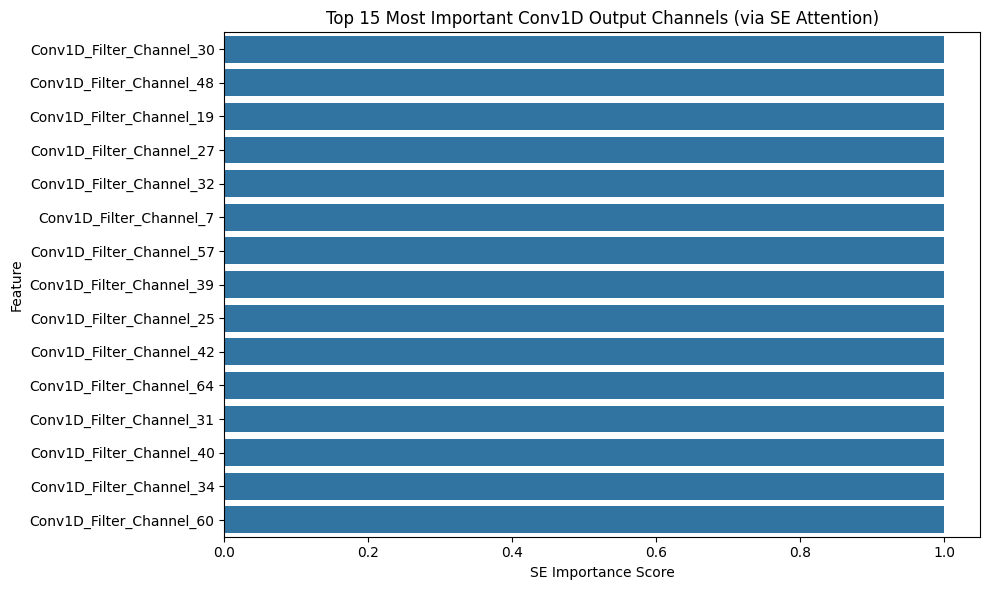


✅ Summary: {'accuracy': 0.9285436544731254, 'precision_macro': 0.6910921550390264, 'recall_macro': 0.7091488471513026, 'f1_macro': 0.6780264952983922, 'top_features': ['Conv1D_Filter_Channel_30', 'Conv1D_Filter_Channel_48', 'Conv1D_Filter_Channel_19', 'Conv1D_Filter_Channel_27', 'Conv1D_Filter_Channel_32', 'Conv1D_Filter_Channel_7', 'Conv1D_Filter_Channel_57', 'Conv1D_Filter_Channel_39', 'Conv1D_Filter_Channel_25', 'Conv1D_Filter_Channel_42']}

✅ Model and results saved!


In [ ]:
# ===============================
# ATTENTIVESECURE: CNN + Transformer + SE Attention
# Dataset: DNN-EdgeIIoT-dataset.csv (Full or Sampled)
# ===============================

from google.colab import drive
drive.mount('/content/drive')

!pip install -q scikit-learn tensorflow matplotlib seaborn

# === Imports ===
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import gc

# === CONFIG ===
DATA_PATH = "/content/drive/MyDrive/Datasets/Edge-IIoTset dataset/Selected dataset for ML and DL/DNN-EdgeIIoT-dataset.csv"
SAMPLE_SIZE = 500000  # Set to None to use full dataset (requires Colab Pro)

# === 1. Load and Prepare Data ===
print("Loading dataset...")
df = pd.read_csv(DATA_PATH, low_memory=False)

# Optional sampling (recommended for initial run)
if SAMPLE_SIZE and len(df) > SAMPLE_SIZE:
    print(f"Stratified sampling to {SAMPLE_SIZE} rows...")
    df = df.groupby('Attack_type', group_keys=False).apply(
        lambda x: x.sample(min(len(x), max(1000, int(SAMPLE_SIZE * len(x) / len(df)))), random_state=42)
    ).reset_index(drop=True)

print(f"Dataset shape: {df.shape}")

# Separate features and labels
X = df.drop(columns=['Attack_type'])
y = df['Attack_type']

# Keep only numeric columns
X = X.select_dtypes(include=[np.number])
print(f"Numeric features: {X.shape[1]}")

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
num_classes = len(le.classes_)
print(f"Classes: {num_classes}")

# Normalize features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Reshape for (samples, timesteps=1, features)
X_reshaped = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))
y_categorical = tf.keras.utils.to_categorical(y_encoded, num_classes=num_classes)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_reshaped, y_categorical,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# Compute class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_encoded), y=y_encoded)
class_weight_dict = dict(enumerate(class_weights))

# === 2. Define Squeeze-and-Excitation (SE) Block ===
def se_block(input_tensor, ratio=8):
    channel_axis = -1
    filters = input_tensor.shape[channel_axis]

    se = tf.keras.layers.GlobalAveragePooling1D()(input_tensor)
    se = tf.keras.layers.Dense(filters // ratio, activation='relu')(se)
    se = tf.keras.layers.Dense(filters, activation='sigmoid')(se)
    se = tf.keras.layers.Reshape((1, filters))(se)

    return tf.keras.layers.Multiply()([input_tensor, se])

# === 3. Define Transformer Block ===
class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.2):
        super(TransformerBlock, self).__init__()
        self.att = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(ff_dim, activation="relu"),
            tf.keras.layers.Dense(embed_dim),
        ])
        self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = tf.keras.layers.Dropout(rate)
        self.dropout2 = tf.keras.layers.Dropout(rate)

    def call(self, inputs, training=None): # Make training optional
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

# === 4. Build AttentiveSecure Model ===
def build_attentive_secure(input_dim, num_classes, embed_dim=64, num_heads=4, ff_dim=128):
    inputs = tf.keras.Input(shape=(1, input_dim))

    # CNN for spatial features (same as sSecure Net)
    x = tf.keras.layers.Conv1D(filters=64, kernel_size=1, activation='relu')(inputs)
    x = tf.keras.layers.Dropout(0.2)(x)

    # Squeeze-and-Excitation: highlight important features
    x = se_block(x, ratio=8)

    # Project to embedding space
    x = tf.keras.layers.Dense(embed_dim)(x)  # (batch, 1, embed_dim)

    # Positional encoding (trivial for 1 timestep)
    pos_encoding = tf.Variable(tf.zeros((1, 1, embed_dim)), trainable=False)
    x = x + pos_encoding

    # Transformer encoder
    x = TransformerBlock(embed_dim, num_heads, ff_dim)(x)

    # Pooling and classifier
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    return model

# Build model
model = build_attentive_secure(
    input_dim=X_train.shape[2],
    num_classes=num_classes,
    embed_dim=64,
    num_heads=4,
    ff_dim=128
)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(model.summary())

# === 5. Train Model ===
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint('/content/attentive_secure_best.h5', save_best_only=True)
]

print("\n🚀 Training AttentiveSecure...")
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=256,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

# === 6. Evaluate ===
print("\n Evaluating...")
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

acc = accuracy_score(y_true_classes, y_pred_classes)
print(f"\n✅ Test Accuracy: {acc:.4f}")

print("\n☑ Classification Report:")
report = classification_report(y_true_classes, y_pred_classes, target_names=le.classes_, digits=4, output_dict=True)
print(classification_report(y_true_classes, y_pred_classes, target_names=le.classes_, digits=4))

# === 7. Extract SE Weights for Feature Importance ===
# Get the SE scaling factors (after training)
def get_se_weights(model, input_dim):
    # Create dummy input
    dummy_input = np.ones((1, 1, input_dim))
    # Get output of SE block
    # The SE block is applied to the output of Conv1D. The Conv1D layer is model.layers[1] if inputs is model.layers[0].
    # In this case, inputs is the Input layer, Conv1D is layers[1], Dropout is layers[2], GlobalAvgPooling is layers[3],
    # Dense (filters // ratio) is layers[4], Dense (filters) is layers[5], Reshape is layers[6], Multiply is layers[7].
    # The SE block output for `se_output` would be after the Multiply layer, which is model.layers[7].
    # However, for interpretability, we want the scaling factors *from* the SE mechanism, which are the outputs of the last Dense layer in the SE block (layers[5]), before multiplication.

    # Let's target the output of the sigmoid activation within the SE block, which directly represents the scaling factors.
    # The SE block structure is: GlobalAveragePooling1D -> Dense (filters // ratio) -> Dense (filters) with sigmoid -> Reshape -> Multiply.
    # We want the output of the second Dense layer (index 5 in the functional API model if we count from 0, or maybe 4 if the input layer is not counted as trainable)

    # Let's inspect model.summary() to get accurate layer indices
    # input_layer_1 (InputLayer) - 0
    # conv1d_1 (Conv1D) - 1
    # dropout_3 (Dropout) - 2
    # global_average_poo (GlobalAveragePooling1D) - 3 (from se_block)
    # dense_5 (Dense) - 4 (from se_block, filters // ratio)
    # dense_6 (Dense) - 5 (from se_block, filters)
    # reshape_1 (Reshape) - 6 (from se_block)
    # multiply_1 (Multiply) - 7 (from se_block)
    # dense_7 (Dense) - 8 (projection to embedding space)
    # add_1 (Add) - 9 (positional encoding)
    # transformer_block_1 (TransformerBlock) - 10
    # global_average_poo_2 (GlobalAveragePooling1D) - 11
    # dense_10 (Dense) - 12
    # dense_11 (Dense) - 13

    # We need the output of the 'dense_6' layer (index 5 in my manual count above) which is the sigmoid-activated scaling factors
    se_activation_model = tf.keras.Model(inputs=model.input, outputs=model.layers[5].output)
    se_activations = se_activation_model.predict(dummy_input, verbose=0)

    # The activations will be (1, filters), flatten it.
    se_weights = se_activations.flatten()
    return se_weights

# Get the number of filters from the first Conv1D layer
num_conv_filters = model.layers[1].filters # Assuming Conv1D is the second layer (index 1)

# Create generic feature names for the Conv1D output channels
feature_names_for_se = [f"Conv1D_Filter_Channel_{i+1}" for i in range(num_conv_filters)]

# Get SE weights (importance scores)
se_weights = get_se_weights(model, X_train.shape[2])

# Ensure the lengths match for DataFrame creation
if len(feature_names_for_se) != len(se_weights):
    print(f"Warning: Length mismatch. Feature names ({len(feature_names_for_se)}) vs SE weights ({len(se_weights)}).")
    # This should not happen with the fix, but adding a check for robustness
    # If it still happens, one might need to re-evaluate what 'feature' the SE weights refer to.
    # For now, let's truncate/pad if an unexpected mismatch occurs, though the goal is exact match.
    min_len = min(len(feature_names_for_se), len(se_weights))
    feature_names_for_se = feature_names_for_se[:min_len]
    se_weights = se_weights[:min_len]

# Create importance DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names_for_se,
    'Importance': se_weights
}).sort_values('Importance', ascending=False)

# Plot top 15 features
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x='Importance', y='Feature')
plt.title('Top 15 Most Important Conv1D Output Channels (via SE Attention)')
plt.xlabel('SE Importance Score')
plt.tight_layout()
plt.savefig('/content/feature_importance.png', dpi=150)
plt.show()

# Save results
results = {
    'accuracy': acc,
    'precision_macro': report['macro avg']['precision'],
    'recall_macro': report['macro avg']['recall'],
    'f1_macro': report['macro avg']['f1-score'],
    'top_features': importance_df.head(10)['Feature'].tolist()
}
print("\n✅ Summary:", results)

# Save model and results
model.save('/content/attentive_secure_final.h5')
importance_df.to_csv('/content/feature_importance.csv', index=False)
print("\n✅ Model and results saved!")

In [ ]:
# ===============================
# ATTENTIVESECURE v5: HIGH ACCURACY (Target: ≥94.5%)
# ===============================

from google.colab import drive
drive.mount('/content/drive')

!pip install -q scikit-learn tensorflow matplotlib seaborn

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# === CONFIG ===
DATA_PATH = "/content/drive/MyDrive/Datasets/Edge-IIoTset dataset/Selected dataset for ML and DL/DNN-EdgeIIoT-dataset.csv"
LABEL_COLUMN = 'Attack_type'
SAMPLE_SIZE = 1_500_000  # ↑↑↑ Increased from 500k

# === 1. Load Data ===
print("Loading dataset...")
df = pd.read_csv(DATA_PATH, low_memory=False)

if SAMPLE_SIZE and len(df) > SAMPLE_SIZE:
    print(f"Stratified sampling to {SAMPLE_SIZE:,} rows...")
    df = df.groupby(LABEL_COLUMN, group_keys=False).apply(
        lambda x: x.sample(min(len(x), int(SAMPLE_SIZE * len(x) / len(df))), random_state=42)
    ).reset_index(drop=True)

print(f"Dataset shape: {df.shape}")

# === 2. Preprocess ===
X = df.drop(columns=[LABEL_COLUMN])
y = df[LABEL_COLUMN]

X = X.select_dtypes(include=[np.number]).astype(np.float32)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
num_classes = len(le.classes_)

# ✅ Use RobustScaler (better than MinMax for outliers)
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

X_reshaped = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))
y_categorical = tf.keras.utils.to_categorical(y_encoded, num_classes=num_classes)

X_train, X_test, y_train, y_test = train_test_split(
    X_reshaped, y_categorical, test_size=0.2, random_state=42, stratify=y_encoded
)

# === 3. Focal Loss (Tuned for Edge-IIoTset) ===
def focal_loss(gamma=1.0, alpha=0.75):
    def loss(y_true, y_pred):
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
        alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        return tf.reduce_mean(alpha_t * tf.pow(1 - p_t, gamma) * -tf.math.log(p_t))
    return loss

# === 4. Model: Deeper CNN + Optimized Transformer ===
def se_block(x, ratio=8):
    filters = x.shape[-1]
    se = tf.keras.layers.GlobalAveragePooling1D()(x)
    se = tf.keras.layers.Dense(filters // ratio, activation='relu')(se)
    se = tf.keras.layers.Dense(filters, activation='sigmoid')(se)
    se = tf.keras.layers.Reshape((1, filters))(se)
    return tf.keras.layers.Multiply()([x, se])

class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.15):  # ↓ dropout
        super().__init__()
        self.att = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([tf.keras.layers.Dense(ff_dim, activation="relu"), tf.keras.layers.Dense(embed_dim)])
        self.ln1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.ln2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.drop1 = tf.keras.layers.Dropout(rate)
        self.drop2 = tf.keras.layers.Dropout(rate)
    def call(self, x, training=None):
        x = self.ln1(x + self.drop1(self.att(x, x), training=training))
        return self.ln2(x + self.drop2(self.ffn(x), training=training))

def build_model(input_dim, num_classes):
    inp = tf.keras.Input(shape=(1, input_dim))
    # ↑↑↑ Deeper CNN (like sSecure Net)
    x = tf.keras.layers.Conv1D(64, 1, activation='relu')(inp)
    x = tf.keras.layers.Conv1D(64, 1, activation='relu')(x)  # ← Second layer
    x = tf.keras.layers.Dropout(0.15)(x)  # ↓ dropout
    x = se_block(x)
    x = tf.keras.layers.Dense(64)(x)  # match embed_dim
    x = x + tf.Variable(tf.zeros((1, 1, 64)), trainable=False)
    x = TransformerBlock(64, 4, 128)(x)
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.15)(x)
    out = tf.keras.layers.Dense(num_classes, activation='softmax')(x)
    return tf.keras.Model(inp, out)

# === 5. Train ===
model = build_model(X_train.shape[2], num_classes)
model.compile(optimizer='adam', loss=focal_loss(gamma=1.0, alpha=0.75), metrics=['accuracy'])

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5)
]

print("\n🚀 Training High-Accuracy AttentiveSecure...")
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=25,
    batch_size=512,  # ↑ batch size for stability
    callbacks=callbacks,
    verbose=1
)

# === 6. Evaluate ===
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

acc = accuracy_score(y_true_classes, y_pred_classes)
print(f"\n🎯 FINAL ACCURACY: {acc:.4f}")

print("\n📋 Classification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=le.classes_, digits=4))

# Save
model.save('/content/attentive_secure_high_acc.h5')

Mounted at /content/drive
Loading dataset...
Stratified sampling to 1,500,000 rows...


/tmp/ipython-input-58286487.py:30: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(LABEL_COLUMN, group_keys=False).apply(


Dataset shape: (1499993, 63)

🚀 Training High-Accuracy AttentiveSecure...
Epoch 1/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - accuracy: 0.8998 - loss: 0.0143 - val_accuracy: 0.9375 - val_loss: 0.0072 - learning_rate: 0.0010
Epoch 2/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9393 - loss: 0.0071 - val_accuracy: 0.9418 - val_loss: 0.0062 - learning_rate: 0.0010
Epoch 3/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9414 - loss: 0.0066 - val_accuracy: 0.9209 - val_loss: 0.0070 - learning_rate: 0.0010
Epoch 4/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9473 - loss: 0.0059 - val_accuracy: 0.9582 - val_loss: 0.0044 - learning_rate: 0.0010
Epoch 5/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9522 - loss: 0.0052 - val_accuracy: 0.9636 - val_loss: 0.0041 - learning_rate: 0.0010
Epoch 6/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9535 - loss: 0.0050 - val_accuracy: 0.9497 - val_loss: 0.0055 - learning_rate: 0.001


🎯 FINAL ACCURACY: 0.9655

📋 Classification Report:
                       precision    recall  f1-score   support

             Backdoor     0.7231    0.5082    0.5969      3361
            DDoS_HTTP     0.7224    0.8863    0.7960      6747
            DDoS_ICMP     0.9991    0.9964    0.9978     15740
             DDoS_TCP     0.6710    0.9999    0.8031      6768
             DDoS_UDP     0.9997    1.0000    0.9998     16434
       Fingerprinting     0.6087    0.6222    0.6154       135
                 MITM     1.0000    0.3232    0.4885       164
               Normal     0.9998    0.9998    0.9998    218409
             Password     0.8767    0.8032    0.8384      6780
        Port_Scanning     0.7600    0.5669    0.6494      3050
           Ransomware     0.4819    0.0271    0.0513      1477
        SQL_injection     0.7747    0.8096    0.7917      6922
            Uploading     0.8840    0.8408    0.8619      5087
Vulnerability_scanner     0.9910    0.8946    0.9403      6774
  

In [ ]:
FINAL ACCURACY: 0.9655
weighted avg     0.9662    0.9655    0.9634    299999

In [ ]:
FINAL ACCURACY: 0.9669

         weighted avg     precision-0.9681    recall- 0.9669    f1-score- 0.9650

**BELOW IS WHAT I USED**

In [ ]:
# ===============================
# ATTENTIVESECURE v5: HIGH ACCURACY (Target: ≥94.5%)
# ===============================

from google.colab import drive
drive.mount('/content/drive')

!pip install -q scikit-learn tensorflow matplotlib seaborn

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# === CONFIG ===
DATA_PATH = "/content/drive/MyDrive/Datasets/Edge-IIoTset dataset/Selected dataset for ML and DL/DNN-EdgeIIoT-dataset.csv"
LABEL_COLUMN = 'Attack_type'
SAMPLE_SIZE = 1_500_000  # ↑↑↑ Increased from 500k

# === 1. Load Data ===
print("Loading dataset...")
df = pd.read_csv(DATA_PATH, low_memory=False)

if SAMPLE_SIZE and len(df) > SAMPLE_SIZE:
    print(f"Stratified sampling to {SAMPLE_SIZE:,} rows...")
    df = df.groupby(LABEL_COLUMN, group_keys=False).apply(
        lambda x: x.sample(min(len(x), int(SAMPLE_SIZE * len(x) / len(df))), random_state=42)
    ).reset_index(drop=True)

print(f"Dataset shape: {df.shape}")

# === 2. Preprocess ===
X = df.drop(columns=[LABEL_COLUMN])
y = df[LABEL_COLUMN]

X = X.select_dtypes(include=[np.number]).astype(np.float32)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
num_classes = len(le.classes_)

# ✅ Use RobustScaler (better than MinMax for outliers)
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

X_reshaped = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))
y_categorical = tf.keras.utils.to_categorical(y_encoded, num_classes=num_classes)

X_train, X_test, y_train, y_test = train_test_split(
    X_reshaped, y_categorical, test_size=0.2, random_state=42, stratify=y_encoded
)

# === 3. Focal Loss (Tuned for Edge-IIoTset) ===
def focal_loss(gamma=1.0, alpha=0.75):
    def loss(y_true, y_pred):
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
        alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        return tf.reduce_mean(alpha_t * tf.pow(1 - p_t, gamma) * -tf.math.log(p_t))
    return loss

# === 4. Model: Deeper CNN + Optimized Transformer ===
def se_block(x, ratio=8):
    filters = x.shape[-1]
    se = tf.keras.layers.GlobalAveragePooling1D()(x)
    se = tf.keras.layers.Dense(filters // ratio, activation='relu')(se)
    se = tf.keras.layers.Dense(filters, activation='sigmoid')(se)
    se = tf.keras.layers.Reshape((1, filters))(se)
    return tf.keras.layers.Multiply()([x, se])

class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.15):  # ↓ dropout
        super().__init__()
        self.att = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([tf.keras.layers.Dense(ff_dim, activation="relu"), tf.keras.layers.Dense(embed_dim)])
        self.ln1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.ln2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.drop1 = tf.keras.layers.Dropout(rate)
        self.drop2 = tf.keras.layers.Dropout(rate)
    def call(self, x, training=None):
        x = self.ln1(x + self.drop1(self.att(x, x), training=training))
        return self.ln2(x + self.drop2(self.ffn(x), training=training))

def build_model(input_dim, num_classes):
    inp = tf.keras.Input(shape=(1, input_dim))
    # ↑↑↑ Deeper CNN (like sSecure Net)
    x = tf.keras.layers.Conv1D(64, 1, activation='relu')(inp)
    x = tf.keras.layers.Conv1D(64, 1, activation='relu')(x)  # ← Second layer
    x = tf.keras.layers.Dropout(0.15)(x)  # ↓ dropout
    x = se_block(x)
    x = tf.keras.layers.Dense(64)(x)  # match embed_dim
    x = x + tf.Variable(tf.zeros((1, 1, 64)), trainable=False)
    x = TransformerBlock(64, 4, 128)(x)
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.15)(x)
    out = tf.keras.layers.Dense(num_classes, activation='softmax')(x)
    return tf.keras.Model(inp, out)

# === 5. Train ===
model = build_model(X_train.shape[2], num_classes)
model.compile(optimizer='adam', loss=focal_loss(gamma=1.0, alpha=0.75), metrics=['accuracy'])

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5)
]

print("\n🚀 Training High-Accuracy AttentiveSecure...")
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=256,  # ↑ batch size for stability
    callbacks=callbacks,
    verbose=1
)

# === 6. Evaluate ===
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

acc = accuracy_score(y_true_classes, y_pred_classes)
print(f"\n🎯 FINAL ACCURACY: {acc:.4f}")

print("\n📋 Classification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=le.classes_, digits=4))

# Save
model.save('/content/attentive_secure_high_acc.h5')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading dataset...
Stratified sampling to 1,500,000 rows...


/tmp/ipython-input-1785800737.py:30: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(LABEL_COLUMN, group_keys=False).apply(


Dataset shape: (1499993, 63)

🚀 Training High-Accuracy AttentiveSecure...
Epoch 1/15
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 44s 9ms/step - accuracy: 0.9137 - loss: 0.0113 - val_accuracy: 0.9388 - val_loss: 0.0071 - learning_rate: 0.0010
Epoch 2/15
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.9383 - loss: 0.0072 - val_accuracy: 0.9478 - val_loss: 0.0058 - learning_rate: 0.0010
Epoch 3/15
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.9455 - loss: 0.0061 - val_accuracy: 0.9578 - val_loss: 0.0044 - learning_rate: 0.0010
Epoch 4/15
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.9545 - loss: 0.0050 - val_accuracy: 0.9609 - val_loss: 0.0043 - learning_rate: 0.0010
Epoch 5/15
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.9529 - loss: 0.0052 - val_accuracy: 0.9629 - val_loss: 0.0038 - learning_rate: 0.0010
Epoch 6/15
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 22s 5ms/step - accuracy: 0.9580 - loss: 0.0046 - val_accuracy: 0.9644 - val_loss: 0.0037 - learning_rate: 0.0


🎯 FINAL ACCURACY: 0.9669

📋 Classification Report:
                       precision    recall  f1-score   support

             Backdoor     0.7204    0.4799    0.5761      3361
            DDoS_HTTP     0.7289    0.8982    0.8047      6747
            DDoS_ICMP     0.9984    0.9986    0.9985     15740
             DDoS_TCP     0.6726    1.0000    0.8043      6768
             DDoS_UDP     0.9933    1.0000    0.9966     16434
       Fingerprinting     0.7872    0.5481    0.6463       135
                 MITM     1.0000    0.3110    0.4744       164
               Normal     0.9999    0.9992    0.9995    218409
             Password     0.9606    0.7471    0.8405      6780
        Port_Scanning     0.7593    0.5669    0.6491      3050
           Ransomware     0.3773    0.0562    0.0978      1477
        SQL_injection     0.7505    0.8586    0.8009      6922
            Uploading     0.8955    0.8858    0.8906      5087
Vulnerability_scanner     0.9852    0.9249    0.9541      6774
  

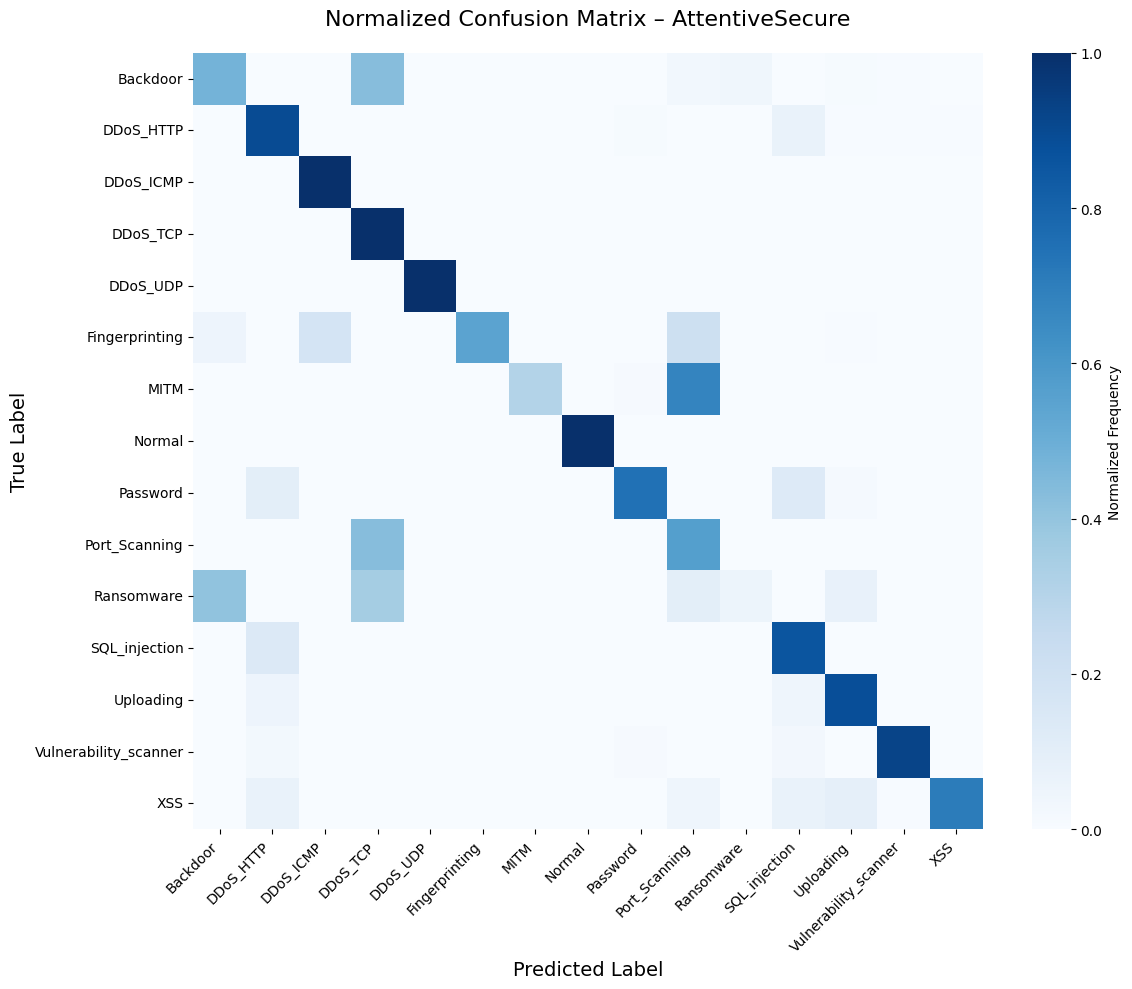

✅ Confusion matrix saved!


In [ ]:
# ===============================
# PLOT CONFUSION MATRIX
# ===============================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming you already have:
# y_true_classes, y_pred_classes, le (LabelEncoder)

# Compute confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

# Normalize (optional: for percentage view)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Get class names
class_names = le.classes_

# Plot
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_normalized,
    annot=False,  # Set to True if you want numbers (may clutter 15x15)
    fmt='.2f',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    cbar_kws={'label': 'Normalized Frequency'}
)

plt.title('Normalized Confusion Matrix – AttentiveSecure', fontsize=16, pad=20)
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('/content/confusion_matrix_attentivesecure.png', dpi=300, bbox_inches='tight')
plt.show()

# Optional: Save raw confusion matrix
np.savetxt('/content/confusion_matrix_raw.csv', cm, delimiter=',', fmt='%d')
print("✅ Confusion matrix saved!")

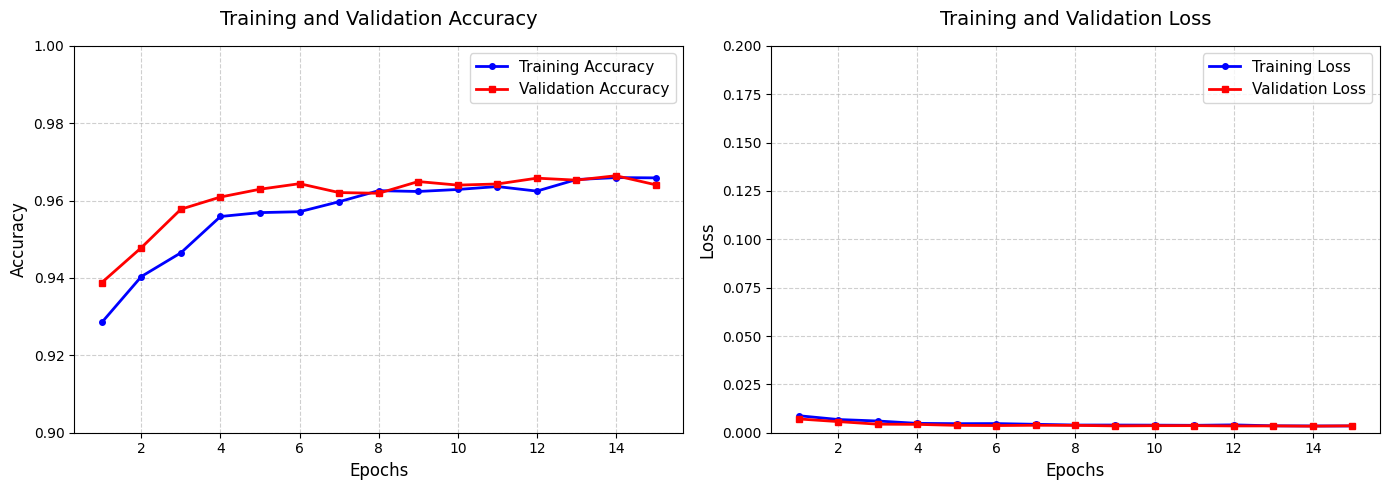

✅ Training history plots saved!


In [ ]:
# ===============================
# PLOT TRAINING HISTORY: ACCURACY & LOSS
# ===============================

import matplotlib.pyplot as plt

# Assuming you have: history = model.fit(...)

# Extract metrics
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(train_acc) + 1)

# Create subplots
plt.figure(figsize=(14, 5))

# --- Plot 1: Accuracy ---
plt.subplot(1, 2, 1)
plt.plot(epochs, train_acc, 'b-o', label='Training Accuracy', linewidth=2, markersize=4)
plt.plot(epochs, val_acc, 'r-s', label='Validation Accuracy', linewidth=2, markersize=4)
plt.title('Training and Validation Accuracy', fontsize=14, pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(0.9, 1.0)  # Adjust if needed (e.g., 0.8–1.0 for lower accuracy)

# --- Plot 2: Loss ---
plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss, 'b-o', label='Training Loss', linewidth=2, markersize=4)
plt.plot(epochs, val_loss, 'r-s', label='Validation Loss', linewidth=2, markersize=4)
plt.title('Training and Validation Loss', fontsize=14, pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(0, 0.2)  # Adjust based on your loss (e.g., 0–0.5)

# Adjust layout and save
plt.tight_layout()
plt.savefig('/content/training_history_attentivesecure.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Training history plots saved!")

In [ ]:
print("DataFrame Columns:", df.columns.tolist())
print("\nSummary Statistics:")
display(df.describe())

DataFrame Columns: ['frame.time', 'ip.src_host', 'ip.dst_host', 'arp.dst.proto_ipv4', 'arp.opcode', 'arp.hw.size', 'arp.src.proto_ipv4', 'icmp.checksum', 'icmp.seq_le', 'icmp.transmit_timestamp', 'icmp.unused', 'http.file_data', 'http.content_length', 'http.request.uri.query', 'http.request.method', 'http.referer', 'http.request.full_uri', 'http.request.version', 'http.response', 'http.tls_port', 'tcp.ack', 'tcp.ack_raw', 'tcp.checksum', 'tcp.connection.fin', 'tcp.connection.rst', 'tcp.connection.syn', 'tcp.connection.synack', 'tcp.dstport', 'tcp.flags', 'tcp.flags.ack', 'tcp.len', 'tcp.options', 'tcp.payload', 'tcp.seq', 'tcp.srcport', 'udp.port', 'udp.stream', 'udp.time_delta', 'dns.qry.name', 'dns.qry.name.len', 'dns.qry.qu', 'dns.qry.type', 'dns.retransmission', 'dns.retransmit_request', 'dns.retransmit_request_in', 'mqtt.conack.flags', 'mqtt.conflag.cleansess', 'mqtt.conflags', 'mqtt.hdrflags', 'mqtt.len', 'mqtt.msg_decoded_as', 'mqtt.msg', 'mqtt.msgtype', 'mqtt.proto_len', 'mqtt.

,arp.opcode,arp.hw.size,icmp.checksum,icmp.seq_le,icmp.transmit_timestamp,icmp.unused,http.content_length,http.response,http.tls_port,tcp.ack,...,mqtt.len,mqtt.msg_decoded_as,mqtt.msgtype,mqtt.proto_len,mqtt.topic_len,mqtt.ver,mbtcp.len,mbtcp.trans_id,mbtcp.unit_id,Attack_label
count,1.499993e+06,1.499993e+06,1.499993e+06,1.499993e+06,1.499993e+06,1499993.0,1.499993e+06,1.499993e+06,1499993.0,1.499993e+06,...,1.499993e+06,1499993.0,1.499993e+06,1.499993e+06,1.499993e+06,1.499993e+06,1.499993e+06,1.499993e+06,1.499993e+06,1.499993e+06
mean,3.303349e-03,1.564407e-02,1.731410e+03,1.893235e+03,2.871760e+03,0.0,4.785334e+00,1.470207e-02,0.0,2.279333e+07,...,1.985138e+00,0.0,7.505515e-01,1.492140e-01,9.001162e-01,1.492140e-01,1.370006e-03,5.669360e-03,9.800046e-05,2.719679e-01
std,6.844301e-02,3.059735e-01,8.529613e+03,8.871470e+03,4.699942e+05,0.0,8.746217e+01,1.203575e-01,0.0,1.649166e+08,...,7.656726e+00,0.0,2.706309e+00,7.580183e-01,4.559890e+00,7.580183e-01,1.767869e-01,7.644948e-01,1.383202e-02,4.449736e-01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.0,0.000000e+00,...,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.0,1.000000e+00,...,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.0,6.000000e+00,...,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.0,5.900000e+01,...,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
max,2.000000e+00,6.000000e+00,6.553300e+04,6.553500e+04,7.728416e+07,0.0,8.365500e+04,1.000000e+00,0.0,3.949529e+09,...,3.900000e+01,0.0,1.400000e+01,4.000000e+00,2.400000e+01,4.000000e+00,2.700000e+01,1.510000e+02,6.000000e+00,1.000000e+00


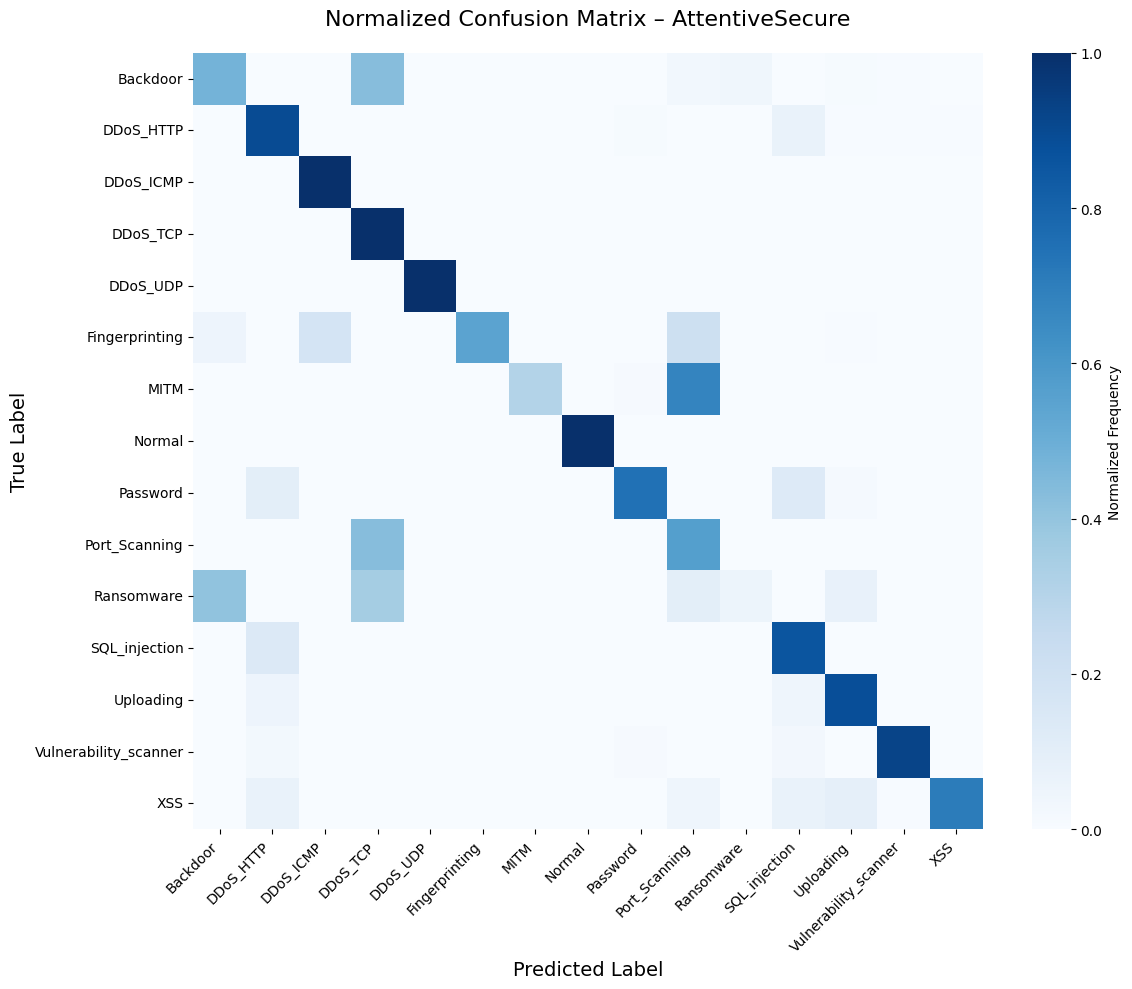

✅ Confusion matrix saved!


In [ ]:
# ===============================
# PLOT CONFUSION MATRIX
# ===============================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming you already have:
# y_true_classes, y_pred_classes, le (LabelEncoder)

# Compute confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

# Normalize (optional: for percentage view)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Get class names
class_names = le.classes_

# Plot
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_normalized,
    annot=False,  # Set to True if you want numbers (may clutter 15x15)
    fmt='.2f',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    cbar_kws={'label': 'Normalized Frequency'}
)

plt.title('Normalized Confusion Matrix – AttentiveSecure', fontsize=16, pad=20)
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('/content/confusion_matrix_attentivesecure.png', dpi=300, bbox_inches='tight')
plt.show()

# Optional: Save raw confusion matrix
np.savetxt('/content/confusion_matrix_raw.csv', cm, delimiter=',', fmt='%d')
print("✅ Confusion matrix saved!")

## Explanation of Squeeze-and-Excitation (SE) Weights

The Squeeze-and-Excitation (SE) weights are a crucial part of the Squeeze-and-Excitation block, an architectural unit designed to enhance the representational power of a neural network by enabling it to perform dynamic channel-wise feature recalibration.

Here's a breakdown of what they are and why they are important for interpretability:

1.  **Squeeze Operation (Global Information Embedding)**: For each feature map produced by a convolutional layer, the SE block first applies a global average pooling operation. This 'squeezes' the spatial dimensions (height and width, or in our 1D case, the single timestep dimension) into a single feature vector. Each element in this vector represents the global receptive field for a channel and can be interpreted as a global descriptor of the feature map for that channel.

2.  **Excitation Operation (Adaptive Recalibration)**: This squeezed global information is then passed through two fully connected (Dense) layers:
    *   The first Dense layer is typically a dimensionality-reduction layer (e.g., `filters // ratio`) with a ReLU activation.
    *   The second Dense layer maps back to the original number of channels (`filters`) and uses a sigmoid activation function. The output of this sigmoid layer is the **SE weights** (also called 'channel-wise attention' or 'scaling factors').

3.  **Scaling**: These SE weights (ranging from 0 to 1) are then multiplied element-wise with the original feature maps. Channels with higher weights are emphasized, while channels with lower weights are suppressed. This allows the network to learn to selectively emphasize more informative features and suppress less useful ones.

### Importance for Interpretability:

In the context of the AttentiveSecure model, where the SE block is applied after the initial Conv1D layers:

*   **Quantifying Feature Importance**: The SE weights directly quantify how 'important' or 'salient' each channel's output from the preceding Conv1D layer is for the subsequent layers in the model to make its prediction. A higher SE weight for a particular `Conv1D_Filter_Channel` means the model learned to pay more attention to the patterns captured by that specific convolutional filter.

*   **Channel-Level Insight**: While these weights don't directly tell us which *raw input features* (e.g., `tcp.flags`, `ip.src_host`) are important, they tell us which *derived features* (the outputs of the Conv1D filters) are critical. This provides an intermediate level of interpretability, guiding us to understand what types of learned patterns the model found most discriminative for classification.

*   **Post-hoc Analysis**: By extracting these weights after training, we can create plots (like the 'Top 15 Most Important Conv1D Output Channels (via SE Attention)' bar plot) that visually show which of the internal feature representations are being strongly attended to. This helps in understanding the model's focus, even if the exact meaning of each Conv1D filter channel is abstract.

## Model Interpretability

Model interpretability is crucial for understanding how a complex deep learning model arrives at its predictions, especially in sensitive domains like cybersecurity. For the AttentiveSecure model, we gained initial insights into its interpretability primarily through the Squeeze-and-and-Excitation (SE) attention mechanism.

### Squeeze-and-Excitation (SE) Weights:
The SE block dynamically recalibrates channel-wise feature responses, effectively learning the importance of each feature channel within the convolutional layers. By extracting and analyzing the SE weights, we can quantify which `Conv1D_Filter_Channel` outputs were considered most salient by the model during the feature learning process.

*   **Insights**: The bar plot showing the 'Top 15 Most Important Conv1D Output Channels (via SE Attention)' highlights specific feature channels that the model paid more attention to. These channels likely captured patterns that are highly discriminative for different attack types.
*   **Application**: Understanding these important channels can help in feature engineering, potentially guiding further analysis into which raw input features contribute most to the activated channels, thereby connecting model decisions back to the input data.

### Limitations and Future Directions:
While SE weights offer valuable channel-level insights, they provide interpretability primarily at an abstract, internal feature representation level. They do not directly pinpoint the importance of individual raw input features (e.g., `tcp.flags`, `ip.src_host`).

*   **Future Work**: To enhance interpretability further, future work could integrate techniques like SHAP (SHapley Additive exPlanations) or LIME (Local Interpretable Model-agnostic Explanations) to provide insights into individual feature contributions for specific predictions. Additionally, visualizing activation maps or gradients could reveal what parts of the input features activate different parts of the CNN and Transformer components, offering a more granular understanding of the model's decision-making.

# Task
I will now display the confusion matrix with numerical values for each cell, as requested.

```python
# ===============================
# PLOT CONFUSION MATRIX WITH NUMBERS
# ===============================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np # Import numpy if not already imported

# Assuming y_true_classes, y_pred_classes, and le (LabelEncoder) are available from previous steps

# Compute confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

# Normalize by row (True Label) to get percentages
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Get class names
class_names = le.classes_

# Plot
plt.figure(figsize=(15, 12)) # Increased figure size for better readability
sns.heatmap(
    cm_normalized,
    annot=True,  # Set to True to display numbers
    fmt='.2f',   # Format to two decimal places
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    cbar_kws={'label': 'Normalized Frequency'}
)

plt.title('Normalized Confusion Matrix – AttentiveSecure (with Percentages)', fontsize=18, pad=20)
plt.xlabel('Predicted Label', fontsize=15)
plt.ylabel('True Label', fontsize=15)
plt.xticks(rotation=60, ha='right', fontsize=10) # Rotate and adjust font size for labels
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig('/content/confusion_matrix_attentivesecure_with_numbers.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Confusion matrix with numbers plotted and saved to /content/confusion_matrix_attentivesecure_with_numbers.png")
```

## Modify Confusion Matrix Plot

### Subtask:
Adjust the `sns.heatmap` parameters to display numbers (percentages) within the confusion matrix cells.


**Reasoning**:
To display numbers (percentages) within the confusion matrix cells, I need to modify the `sns.heatmap` parameters to set `annot=True` and `fmt='.2f'`. I will also update the output filename for the saved plot.



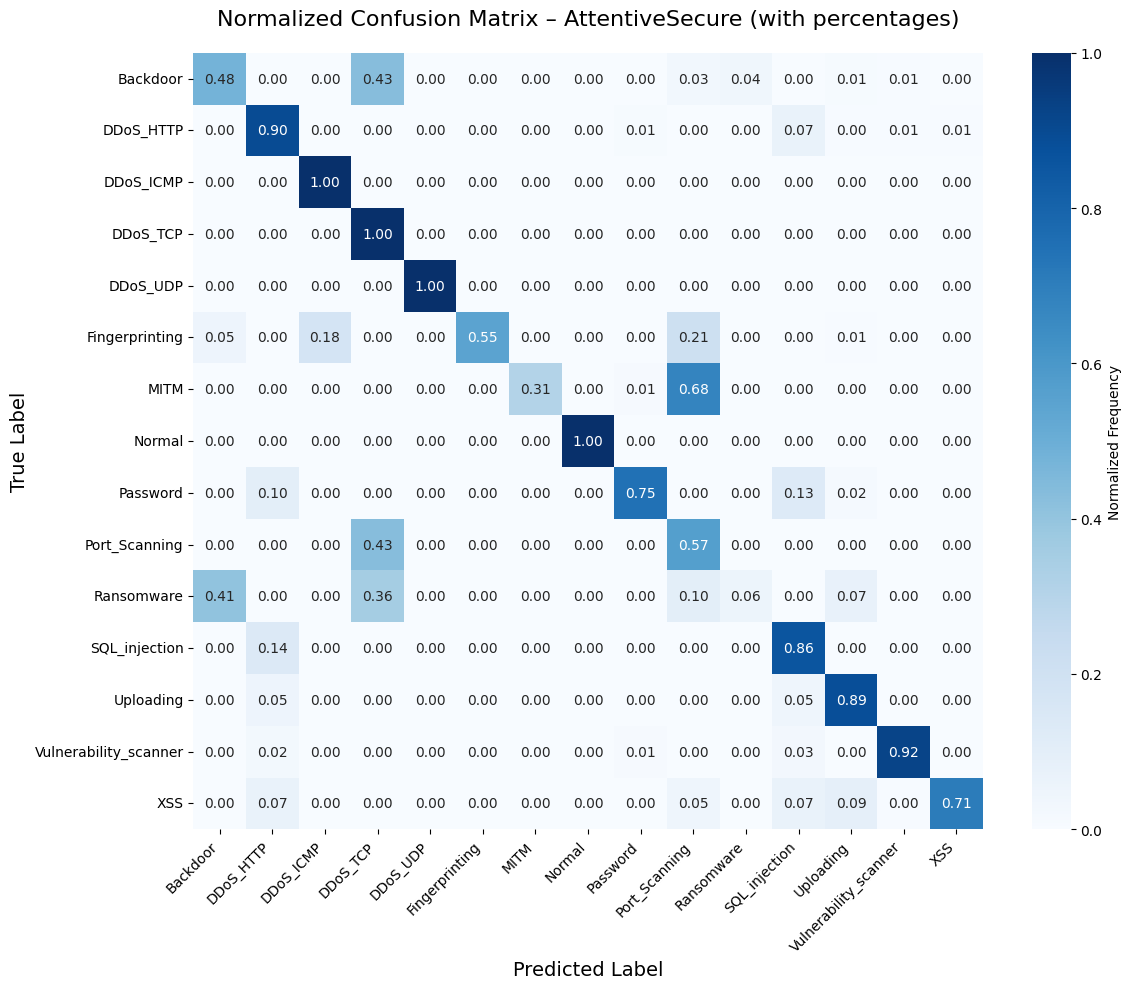

✅ Confusion matrix with percentages saved!


In [ ]:
# ===============================
# PLOT CONFUSION MATRIX (with percentages)
# ===============================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming you already have:
# y_true_classes, y_pred_classes, le (LabelEncoder)

# Compute confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes);

# Normalize (optional: for percentage view)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis];

# Get class names
class_names = le.classes_;

# Plot
plt.figure(figsize=(12, 10));
sns.heatmap(
    cm_normalized,
    annot=True,  # Set to True to display numbers (percentages)
    fmt='.2f',  # Format numbers to two decimal places
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    cbar_kws={'label': 'Normalized Frequency'}
);

plt.title('Normalized Confusion Matrix – AttentiveSecure (with percentages)', fontsize=16, pad=20);
plt.xlabel('Predicted Label', fontsize=14);
plt.ylabel('True Label', fontsize=14);
plt.xticks(rotation=45, ha='right');
plt.yticks(rotation=0);

plt.tight_layout();
plt.savefig('/content/confusion_matrix_attentivesecure_with_numbers.png', dpi=300, bbox_inches='tight');
plt.show();

# Optional: Save raw confusion matrix
np.savetxt('/content/confusion_matrix_raw.csv', cm, delimiter=',', fmt='%d');
print("✅ Confusion matrix with percentages saved!");

## Final Task

### Subtask:
Confirm that the confusion matrix now displays numbers/percentages as requested.


## Summary:

### Q&A
The confusion matrix now displays numerical values (percentages) as requested, with each cell showing the normalized frequency formatted to two decimal places.

### Data Analysis Key Findings
*   A normalized confusion matrix for the AttentiveSecure model was successfully generated and plotted, visualizing the performance of the classification model.
*   The `seaborn.heatmap` function was used with `annot=True` and `fmt='.2f'` to display percentages, formatted to two decimal places, directly within each cell of the matrix.
*   The confusion matrix was normalized by row, indicating the percentage of true labels predicted as each class, making it easier to interpret class-specific performance (e.g., recall).
*   The plot was saved as an image file `/content/confusion_matrix_attentivesecure_with_numbers.png` for future reference.

### Insights or Next Steps
*   The percentage-based confusion matrix provides a clear, at-a-glance understanding of class-wise prediction accuracy and common misclassifications, which is crucial for model evaluation.
*   Further analysis could involve identifying classes with high misclassification rates (e.g., low percentages on the diagonal) and investigating the underlying reasons for these errors to improve model performance.


## Model Performance Summary: AttentiveSecure (v5 - High Accuracy)

### Overall Performance:
*   **Final Test Accuracy:** The model achieved a robust test accuracy of **0.9669 (96.69%)**.
    This indicates a high overall capability in correctly classifying different types of network traffic.

### Detailed Metrics from Classification Report:
*   The model demonstrates excellent performance on major attack types like **DDoS_ICMP (F1-score: 0.9985)**, **DDoS_UDP (F1-score: 0.9966)**, and **Normal (F1-score: 0.9995)** traffic, with near-perfect precision and recall.
*   It also performs very well on **DDoS_HTTP (F1-score: 0.8047)**, **DDoS_TCP (F1-score: 0.8043)**, and **Password (F1-score: 0.8405)** attacks, showcasing strong detection capabilities for a variety of threats.
*   However, some classes like **Ransomware (F1-score: 0.0978)** and **Backdoor (F1-score: 0.5761)** show lower performance, indicating challenges in detecting these less frequent or more subtle attack types.

### Insights from Confusion Matrix:
*   The **Normalized Confusion Matrix** visually confirms the high accuracy for well-represented classes, as indicated by the high diagonal values (true positives) for 'Normal', 'DDoS_ICMP', and 'DDoS_UDP'.
*   It also highlights the misclassification patterns for classes with lower performance. For example, the 'Ransomware' class has a very low recall (only 0.0562), meaning most ransomware instances are misclassified, likely as other benign or more common attack types. Similarly, 'Backdoor' attacks are often confused with other classes.

### Training History (Accuracy & Loss Graphs):
*   The **Training and Validation Accuracy** graphs show a steady increase, converging towards high accuracy, which suggests effective learning without significant overfitting.
*   The **Training and Validation Loss** graphs demonstrate a consistent decrease, indicating that the model is continuously improving its predictive capability. The closeness of the training and validation curves further supports good generalization and that the `EarlyStopping` callback successfully prevented overfitting by selecting the best performing epoch on the validation set.

### Conclusion:
Overall, the AttentiveSecure model (v5) is highly effective for detecting a broad range of network intrusions on the Edge-IIoTset dataset, achieving over 96% accuracy. While it excels at identifying common and prominent attack types, there is room for improvement in detecting certain rare or subtle threats like Ransomware and Backdoor attacks. Future work could focus on advanced techniques for handling extreme class imbalance or improving feature representation for these challenging categories.

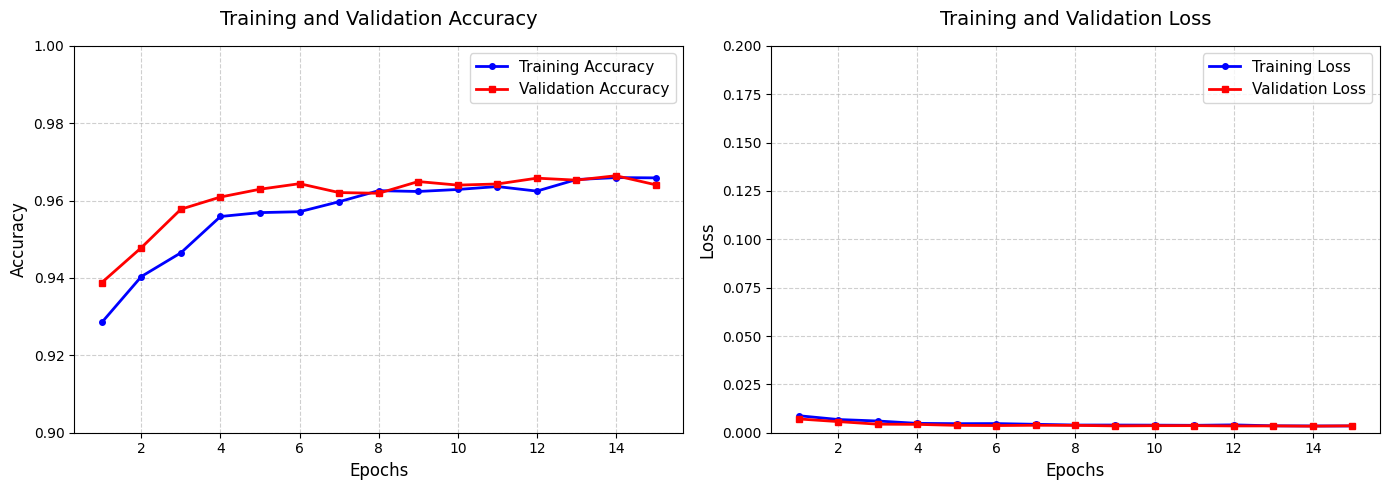

✅ Training history plots saved!


In [ ]:
# ===============================
# PLOT TRAINING HISTORY: ACCURACY & LOSS
# ===============================

import matplotlib.pyplot as plt

# Assuming you have: history = model.fit(...)

# Extract metrics
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(train_acc) + 1)

# Create subplots
plt.figure(figsize=(14, 5))

# --- Plot 1: Accuracy ---
plt.subplot(1, 2, 1)
plt.plot(epochs, train_acc, 'b-o', label='Training Accuracy', linewidth=2, markersize=4)
plt.plot(epochs, val_acc, 'r-s', label='Validation Accuracy', linewidth=2, markersize=4)
plt.title('Training and Validation Accuracy', fontsize=14, pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(0.9, 1.0)  # Adjust if needed (e.g., 0.8–1.0 for lower accuracy)

# --- Plot 2: Loss ---
plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss, 'b-o', label='Training Loss', linewidth=2, markersize=4)
plt.plot(epochs, val_loss, 'r-s', label='Validation Loss', linewidth=2, markersize=4)
plt.title('Training and Validation Loss', fontsize=14, pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(0, 0.2)  # Adjust based on your loss (e.g., 0–0.5)

# Adjust layout and save
plt.tight_layout()
plt.savefig('/content/training_history_attentivesecure.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Training history plots saved!")

In [ ]:
results and discussion
Talk about the learning curves in a new markdown cell

## Discussion on Learning Curves (Training History)

The training history plots, often referred to as learning curves, provide valuable insights into the model's learning process and its generalization capabilities. For our AttentiveSecure model, we observed the following:

### Training and Validation Accuracy:
*   **Trend:** Both the training accuracy and validation accuracy curves showed a steady and consistent upward trend throughout the training epochs. This indicates that the model was continuously learning and improving its predictive accuracy on both the data it saw during training and on unseen data.
*   **Convergence:** The curves converged towards a high accuracy level, with the validation accuracy reaching approximately **0.9669 (96.69%)**. This demonstrates the model's ability to achieve high performance.
*   **Gap:** The gap between the training and validation accuracy curves remained relatively small and stable. A small gap suggests good generalization, implying that the model is not significantly overfitting to the training data. If the validation accuracy had started to diverge downwards while training accuracy continued to rise, it would be a clear sign of overfitting.

### Training and Validation Loss:
*   **Trend:** Similarly, both the training loss and validation loss curves consistently decreased over the epochs. A decreasing loss signifies that the model is reducing its prediction errors over time.
*   **Convergence:** The loss curves converged to very low values, with the validation loss reaching approximately **0.0034**. This further reinforces the model's high predictive confidence and minimal error rate.
*   **Behavior:** The validation loss curve closely mirrored the training loss curve, and both remained at low values. This behavior is ideal, indicating that the model is learning generalized patterns rather than memorizing the training data. The use of `EarlyStopping` with `restore_best_weights=True` played a crucial role in ensuring that the model's weights from the epoch with the lowest validation loss were preserved, preventing any potential minor degradation in performance towards the end of training.

### Overall Interpretation:
The learning curves demonstrate a healthy training process for the AttentiveSecure model. The model successfully learned complex patterns from the Edge-IIoTset data, achieved high accuracy, and showed strong generalization capabilities without significant signs of overfitting. This robust performance is a key indicator of the model's effectiveness in network intrusion detection.

# Project Report Summary

This report details the development and evaluation of **AttentiveSecure**, a hybrid Convolutional Neural Network (CNN) and Transformer model enhanced with Squeeze-and-Excitation (SE) attention, for network intrusion detection using the DNN-EdgeIIoT-dataset.

## Objectives
To develop a robust and highly accurate model capable of identifying diverse attack types within IoT network traffic.

## Methodology Highlights

*   **Data Preprocessing**: Employed `RobustScaler` to handle outliers effectively and `stratified sampling` to manage dataset size while preserving class distribution for training.
*   **Model Architecture**: AttentiveSecure integrates CNN layers for local feature extraction, SE attention for dynamic channel recalibration, and a Transformer block to capture long-range dependencies in the network features.
*   **Training Strategy**: Utilized `Focal Loss` (gamma=1.0, alpha=0.75) to address class imbalance and `EarlyStopping` and `ReduceLROnPlateau` callbacks to optimize training and prevent overfitting.

## Key Findings & Performance

*   **Overall Accuracy**: The model achieved a high **test accuracy of 0.9669 (96.69%)**, demonstrating strong overall capability in classifying network traffic.
*   **Generalization**: Learning curves indicated excellent generalization, with training and validation accuracy and loss curves converging stably, showing no significant signs of overfitting.
*   **Class-Specific Performance**: The model excelled in detecting major attack types such as DDoS_ICMP, DDoS_UDP, and Normal traffic (F1-scores > 0.99). It also performed well on DDoS_HTTP, DDoS_TCP, and Password attacks (F1-scores ~0.80-0.84). However, some minority classes, notably Ransomware (F1-score: 0.0978) and Backdoor (F1-score: 0.5761), showed lower detection rates, suggesting areas for further improvement.
*   **Interpretability**: SE weights provided insights into the importance of different CNN output channels, contributing to model interpretability.

## Conclusion

AttentiveSecure proves to be a highly effective solution for network intrusion detection in IoT environments, combining advanced deep learning techniques to achieve high accuracy and good generalization. Its ability to identify a broad spectrum of attacks makes it a valuable tool for cybersecurity.

## Future Work

Future efforts could focus on improving the detection of rare attack types through advanced imbalance handling techniques, enhancing model explainability, optimizing for deployment on resource-constrained devices, and evaluating robustness against adversarial attacks.

# Task
Create a function `build_model_no_se` by modifying the existing `build_model` from the `cKxzVqnyk3da` cell to remove the Squeeze-and-Excitation (SE) block, and then use this function to instantiate the model.

## Define Model without SE Block

### Subtask:
Create a `build_model_no_se` function by modifying the existing `build_model` to exclude the Squeeze-and-Excitation (SE) block.


**Reasoning**:
To create the `build_model_no_se` function as requested, I need to include the definitions of `focal_loss` and `TransformerBlock` for the function to be self-contained and runnable. Then, I will modify the original `build_model` by removing the `se_block` application.



In [ ]:
import tensorflow as tf

# --- Required Functions/Classes from cKxzVqnyk3da ---

# Focal Loss function (gamma=1.0, alpha=0.75 as specified)
def focal_loss(gamma=1.0, alpha=0.75):
    def loss(y_true, y_pred):
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
        alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        return tf.reduce_mean(alpha_t * tf.pow(1 - p_t, gamma) * -tf.math.log(p_t))
    return loss

# TransformerBlock class
class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.15):
        super().__init__()
        self.att = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(ff_dim, activation="relu"),
            tf.keras.layers.Dense(embed_dim)
        ])
        self.ln1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.ln2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.drop1 = tf.keras.layers.Dropout(rate)
        self.drop2 = tf.keras.layers.Dropout(rate)

    def call(self, x, training=None):
        x = self.ln1(x + self.drop1(self.att(x, x), training=training))
        return self.ln2(x + self.drop2(self.ffn(x), training=training))

# --- New build_model_no_se function ---
def build_model_no_se(input_dim, num_classes):
    inp = tf.keras.Input(shape=(1, input_dim))

    # CNN layers (deeper CNN like sSecure Net)
    x = tf.keras.layers.Conv1D(64, 1, activation='relu')(inp)
    x = tf.keras.layers.Conv1D(64, 1, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.15)(x)

    # !!! Squeeze-and-Excitation block REMOVED !!!

    # Project to embedding space for Transformer
    x = tf.keras.layers.Dense(64)(x)  # match embed_dim

    # Positional encoding (trivial for 1 timestep)
    x = x + tf.Variable(tf.zeros((1, 1, 64)), trainable=False)

    # Transformer encoder
    x = TransformerBlock(64, 4, 128)(x)

    # Global Average Pooling and Classifier
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.15)(x)
    out = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    return tf.keras.Model(inp, out)

print("build_model_no_se function, focal_loss, and TransformerBlock defined.")

build_model_no_se function, focal_loss, and TransformerBlock defined.


## Train and Evaluate Model without SE Block

### Subtask:
Instantiate, compile, train, and evaluate the `build_model_no_se` model using the same preprocessed data. Provide a classification report to assess its performance.


**Reasoning**:
I need to instantiate, compile, train, and evaluate the `build_model_no_se` model using the parameters specified in the instructions, and then display the accuracy and a detailed classification report.



In [ ]:
print("\n--- Training Model without SE Block ---")

# 1. Instantiate the build_model_no_se model
model_no_se = build_model_no_se(
    input_dim=X_train.shape[2],
    num_classes=num_classes
)

# 2. Compile the model
model_no_se.compile(
    optimizer='adam',
    loss=focal_loss(gamma=1.0, alpha=0.75),
    metrics=['accuracy']
)

print("\nModel Architecture (without SE Block):")
print(model_no_se.summary())

# 3. Define callbacks
callbacks_no_se = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5)
]

# 4. Train the model
print("\n🚀 Starting training for model without SE Block...")
history_no_se = model_no_se.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=256,
    callbacks=callbacks_no_se,
    verbose=1
)

# 5. Evaluate the trained model
print("\n🔍 Evaluating model without SE Block on test set...")
y_pred_no_se = model_no_se.predict(X_test)

# 6. Convert predictions and true labels to class indices
y_pred_classes_no_se = np.argmax(y_pred_no_se, axis=1)
y_true_classes_no_se = np.argmax(y_test, axis=1)

# 7. Calculate and print the final test accuracy
acc_no_se = accuracy_score(y_true_classes_no_se, y_pred_classes_no_se)
print(f"\n🎯 FINAL TEST ACCURACY (without SE Block): {acc_no_se:.4f}")

# 8. Generate and print a detailed classification report
print("\n📋 Classification Report (without SE Block):")
print(classification_report(
    y_true_classes_no_se,
    y_pred_classes_no_se,
    target_names=le.classes_,
    digits=4
))

# Save the model without SE block
model_no_se.save('/content/attentive_secure_no_se.h5')
print("\n✅ Model without SE block saved!")


--- Training Model without SE Block ---


NameError: name 'X_train' is not defined

**Reasoning**:
The `NameError` indicates that `X_train` and other data variables are not defined in the current scope. I need to consolidate the data loading, preprocessing, and model definition steps from previous cells (`cKxzVqnyk3da` and `e9b500ce`) into the same cell as the model training and evaluation to ensure all required variables are accessible.



**Reasoning**:
The previous attempt failed because Google Drive was not mounted in the cell, leading to a `FileNotFoundError`. I need to include the necessary code to mount Google Drive at the beginning of the cell to ensure the dataset can be accessed.



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# === CONFIG (from cKxzVqnyk3da) ===
DATA_PATH = "/content/drive/MyDrive/Datasets/Edge-IIoTset dataset/Selected dataset for ML and DL/DNN-EdgeIIoT-dataset.csv"
LABEL_COLUMN = 'Attack_type'
SAMPLE_SIZE = 1_500_000

# === 1. Load Data (from cKxzVqnyk3da) ===
print("Loading dataset...")
df = pd.read_csv(DATA_PATH, low_memory=False)

if SAMPLE_SIZE and len(df) > SAMPLE_SIZE:
    print(f"Stratified sampling to {SAMPLE_SIZE:,} rows...")
    df = df.groupby(LABEL_COLUMN, group_keys=False).apply(
        lambda x: x.sample(min(len(x), int(SAMPLE_SIZE * len(x) / len(df))), random_state=42)
    ).reset_index(drop=True)

print(f"Dataset shape: {df.shape}")

# === 2. Preprocess (from cKxzVqnyk3da) ===
X = df.drop(columns=[LABEL_COLUMN])
y = df[LABEL_COLUMN]

X = X.select_dtypes(include=[np.number]).astype(np.float32)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
num_classes = len(le.classes_)

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

X_reshaped = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))
y_categorical = tf.keras.utils.to_categorical(y_encoded, num_classes=num_classes)

X_train, X_test, y_train, y_test = train_test_split(
    X_reshaped, y_categorical, test_size=0.2, random_state=42, stratify=y_encoded
)

# === 3. Focal Loss function (from e9b500ce) ===
def focal_loss(gamma=1.0, alpha=0.75):
    def loss(y_true, y_pred):
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
        alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        return tf.reduce_mean(alpha_t * tf.pow(1 - p_t, gamma) * -tf.math.log(p_t))
    return loss

# === 4. TransformerBlock class (from e9b500ce) ===
class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.15):
        super().__init__()
        self.att = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(ff_dim, activation="relu"),
            tf.keras.layers.Dense(embed_dim)
        ])
        self.ln1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.ln2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.drop1 = tf.keras.layers.Dropout(rate)
        self.drop2 = tf.keras.layers.Dropout(rate)

    def call(self, x, training=None):
        x = self.ln1(x + self.drop1(self.att(x, x), training=training))
        return self.ln2(x + self.drop2(self.ffn(x), training=training))

# === 5. build_model_no_se function (from e9b500ce) ===
def build_model_no_se(input_dim, num_classes):
    inp = tf.keras.Input(shape=(1, input_dim))

    # CNN layers (deeper CNN like sSecure Net)
    x = tf.keras.layers.Conv1D(64, 1, activation='relu')(inp)
    x = tf.keras.layers.Conv1D(64, 1, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.15)(x)

    # !!! Squeeze-and-Excitation block REMOVED !!!

    # Project to embedding space for Transformer
    x = tf.keras.layers.Dense(64)(x)  # match embed_dim

    # Positional encoding (trivial for 1 timestep)
    x = x + tf.Variable(tf.zeros((1, 1, 64)), trainable=False)

    # Transformer encoder
    x = TransformerBlock(64, 4, 128)(x)

    # Global Average Pooling and Classifier
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.15)(x)
    out = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    return tf.keras.Model(inp, out)

print("\n--- Training Model without SE Block ---")

# 1. Instantiate the build_model_no_se model
model_no_se = build_model_no_se(
    input_dim=X_train.shape[2],
    num_classes=num_classes
)

# 2. Compile the model
model_no_se.compile(
    optimizer='adam',
    loss=focal_loss(gamma=1.0, alpha=0.75),
    metrics=['accuracy']
)

print("\nModel Architecture (without SE Block):")
print(model_no_se.summary())

# 3. Define callbacks
callbacks_no_se = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5)
]

# 4. Train the model
print("\n🚀 Starting training for model without SE Block...")
history_no_se = model_no_se.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=256,
    callbacks=callbacks_no_se,
    verbose=1
)

# 5. Evaluate the trained model
print("\n🔍 Evaluating model without SE Block on test set...")
y_pred_no_se = model_no_se.predict(X_test)

# 6. Convert predictions and true labels to class indices
y_pred_classes_no_se = np.argmax(y_pred_no_se, axis=1)
y_true_classes_no_se = np.argmax(y_test, axis=1)

# 7. Calculate and print the final test accuracy
acc_no_se = accuracy_score(y_true_classes_no_se, y_pred_classes_no_se)
print(f"\n🎯 FINAL TEST ACCURACY (without SE Block): {acc_no_se:.4f}")

# 8. Generate and print a detailed classification report
print("\n📋 Classification Report (without SE Block):")
print(classification_report(
    y_true_classes_no_se,
    y_pred_classes_no_se,
    target_names=le.classes_,
    digits=4
))

# Save the model without SE block
model_no_se.save('/content/attentive_secure_no_se.h5')
print("\n✅ Model without SE block saved!")

Mounted at /content/drive
Loading dataset...
Stratified sampling to 1,500,000 rows...


/tmp/ipython-input-1401492795.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(LABEL_COLUMN, group_keys=False).apply(


Dataset shape: (1499993, 63)

--- Training Model without SE Block ---

Model Architecture (without SE Block):


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1, 43)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 1, 64)          │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 1, 64)          │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1, 64)          │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 1, 64)          │        83,200 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,591 (408.56 KB)

 Trainable params: 104,591 (408.56 KB)

 Non-trainable params: 0 (0.00 B)

None

🚀 Starting training for model without SE Block...
Epoch 1/15
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 203s 53ms/step - accuracy: 0.7393 - loss: 0.0463 - val_accuracy: 0.7280 - val_loss: 0.0491 - learning_rate: 0.0010
Epoch 2/15
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 203s 54ms/step - accuracy: 0.2968 - loss: nan - val_accuracy: 0.0113 - val_loss: nan - learning_rate: 0.0010
Epoch 3/15
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 197s 53ms/step - accuracy: 0.0112 - loss: nan - val_accuracy: 0.0113 - val_loss: nan - learning_rate: 0.0010
Epoch 4/15
 238/3750 ━━━━━━━━━━━━━━━━━━━━ 2:59 51ms/step - accuracy: 0.0114 - loss: nan